In [1]:
from singleCAM_IROS._pipeline_support import _handle_dirpaths

from pathlib import Path

import numpy as np
import pandas as pd

from bloodmoon.io import simulation_files
from bloodmoon.mask import codedmask

import darksun as ds


skyfield = "GalacticCentre"

mask_FITS = "wfm_mask_NTHT_20250725.fits"
data_FITS = "galctr_rxte-sax_mask_050_1040x17_infdet_2-50keV_1ks"

N_TEST = "singleCAM_iros_testing_optimizerNoPeak_vignettingOFF"

mask_path, simul_data, save_path = _handle_dirpaths(
    mask=mask_FITS,
    skyfield=skyfield,
    simul=data_FITS,
    run_name=N_TEST,
)

UPX, UPY = 5, 1
wfm = codedmask(mask_path, UPX, UPY)

cam_a = "cam1a"
cam_b = "cam1b"
dataset = 'detected'

#filepaths = simulation_files(simul_data)
#sdlA = ds.get_data(filepaths[cam_a][dataset])
#catalogueA = ds.get_catalogue(filepaths[cam_a]['sources'])
#sdlB = ds.get_data(filepaths[cam_b][dataset])
#catalogueB = ds.get_catalogue(filepaths[cam_b]['sources'])

simul_sky_camA, _ = ds.load_sky(save_path + f"sky_SIMUL_CAM1A_TEST_{N_TEST}.fits")
simul_sky_camB, _ = ds.load_sky(save_path + f"sky_SIMUL_CAM1B_TEST_{N_TEST}.fits")
log_camA, log_camB = ds.load_database(save_path + f"IROS_sources_database_TEST_{N_TEST}.fits")

# Loading data...
# Loading completed!
# Loading data...
# Loading completed!
# Loading data...
# Loading completed!


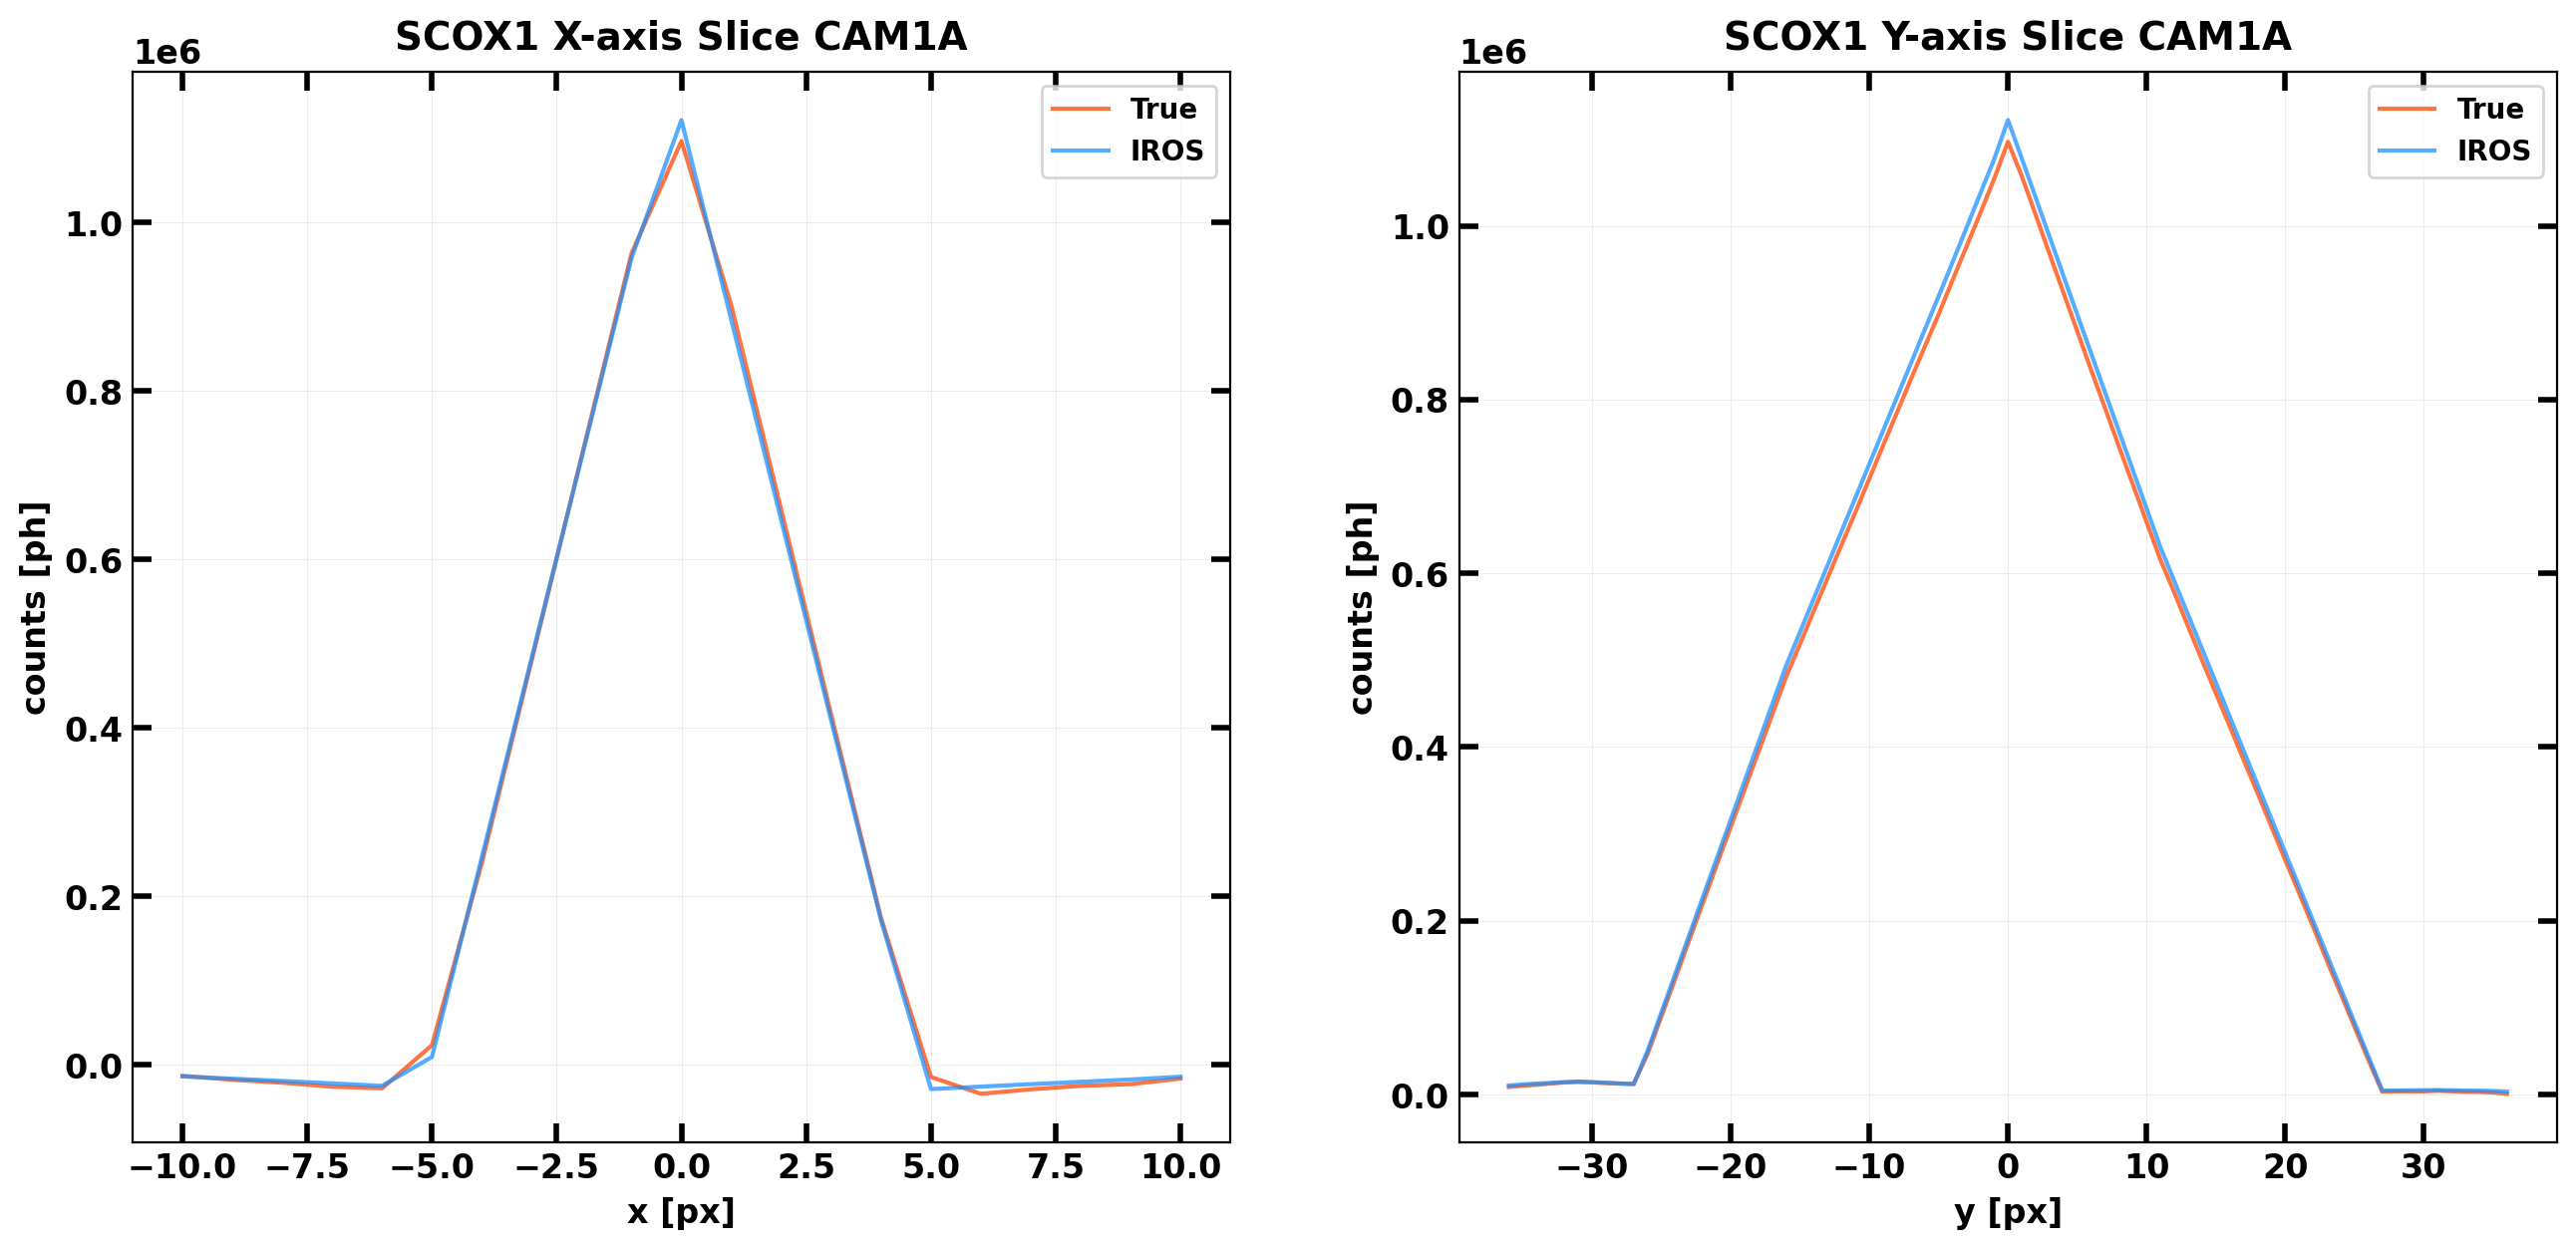

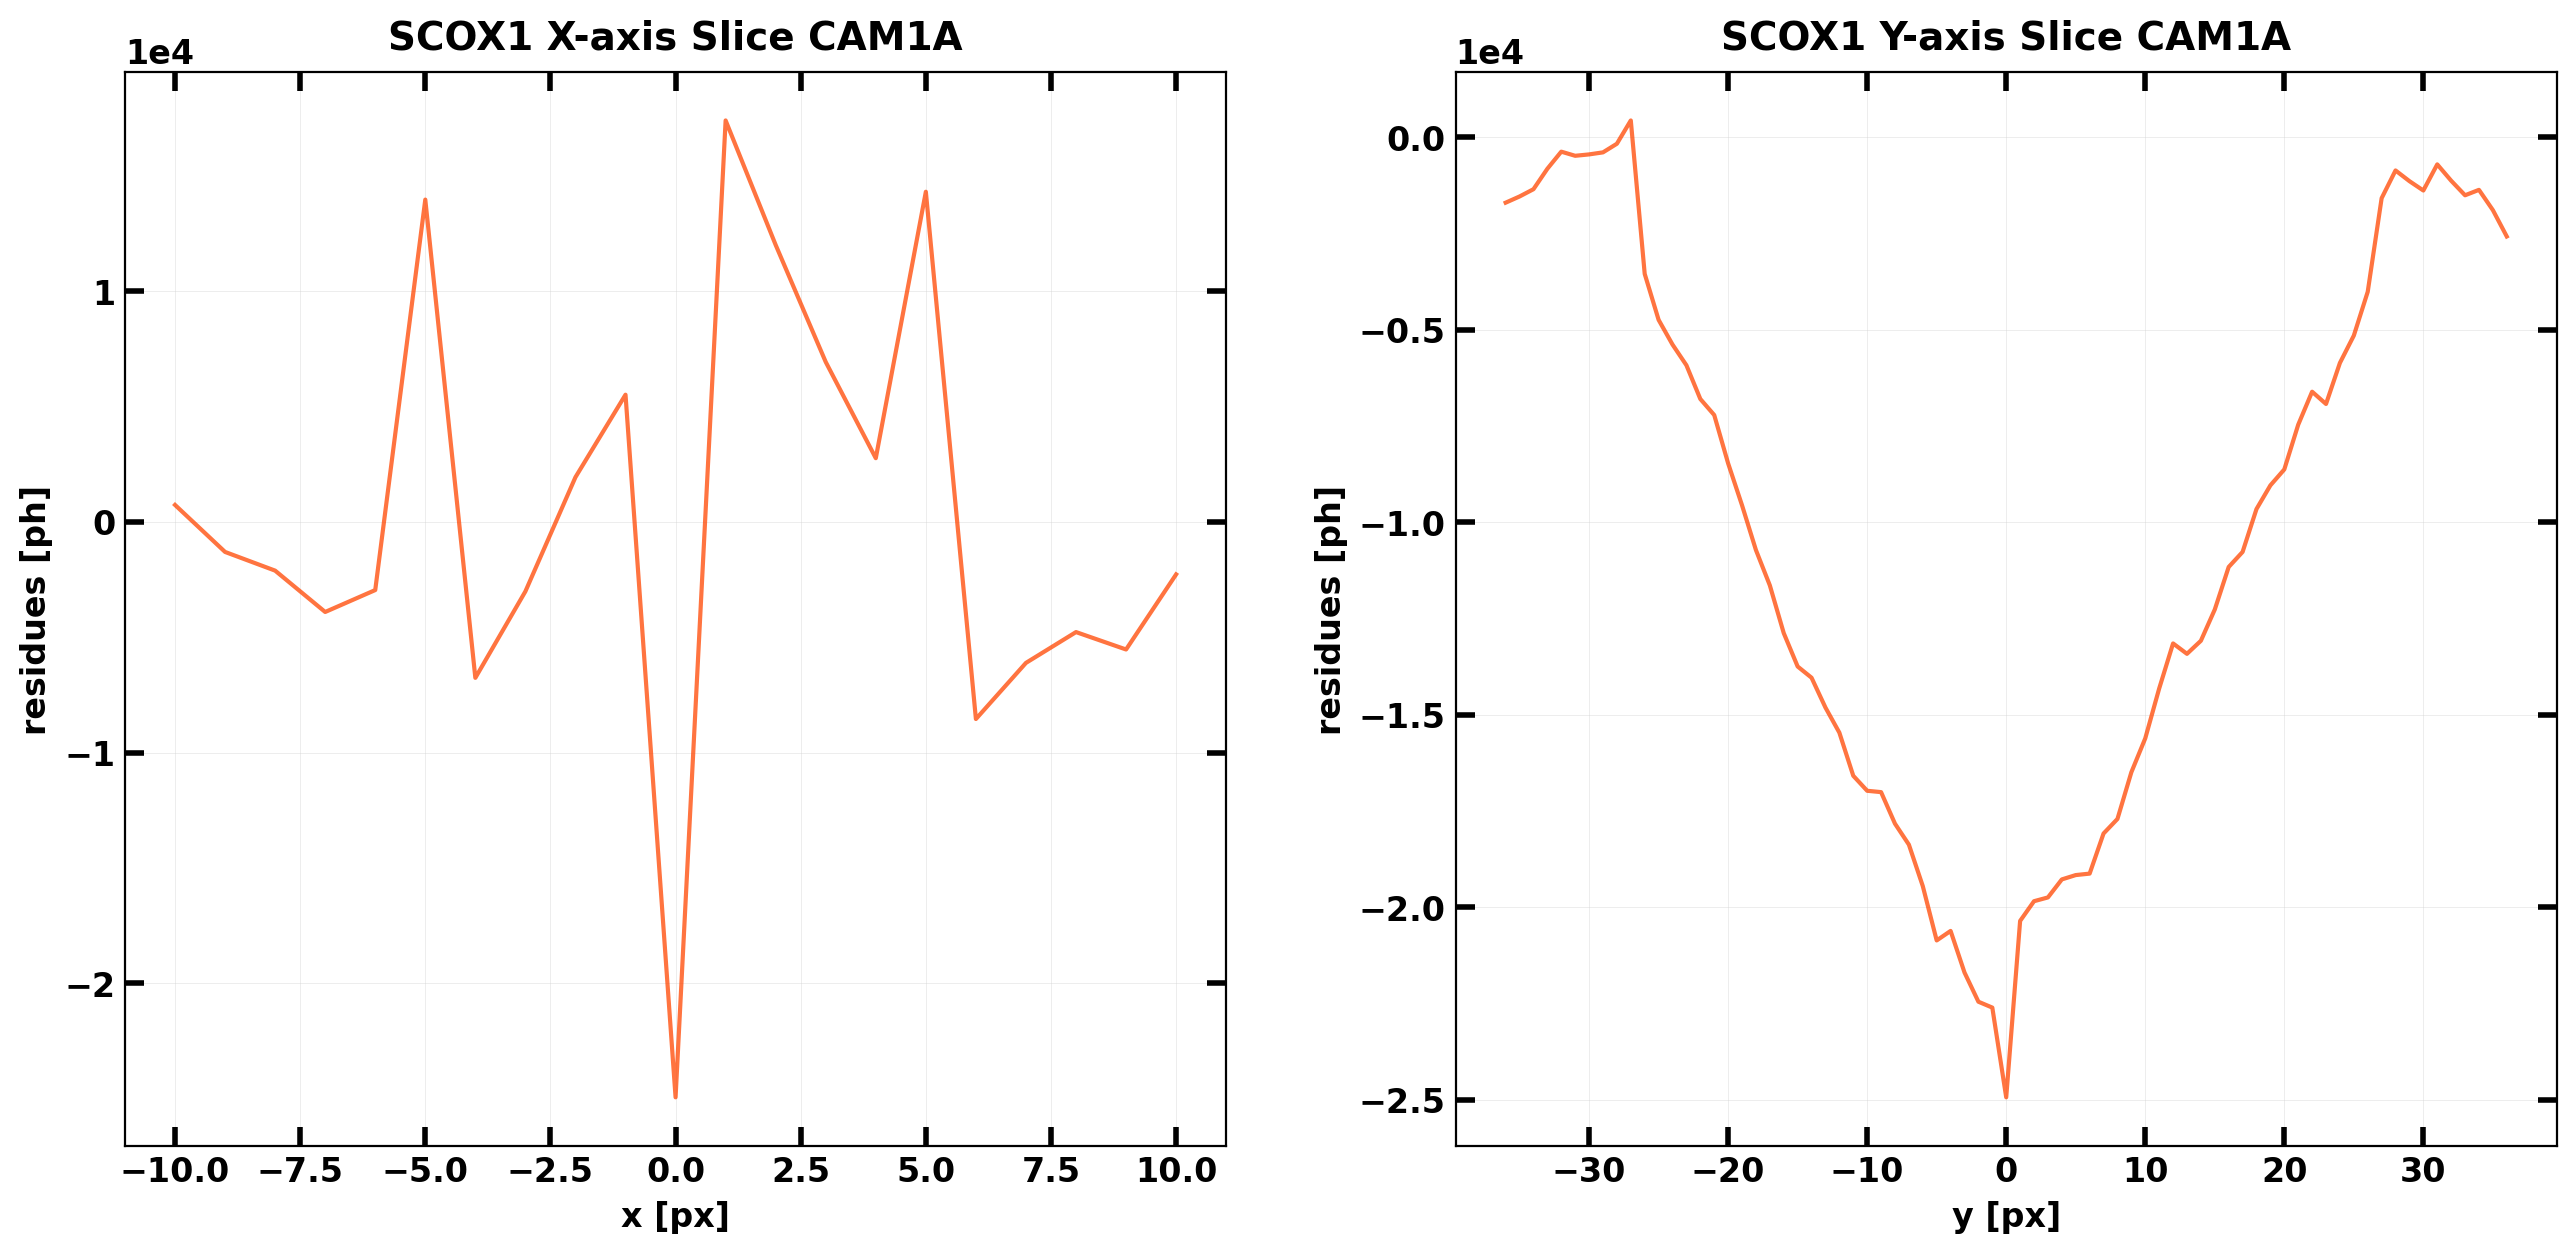

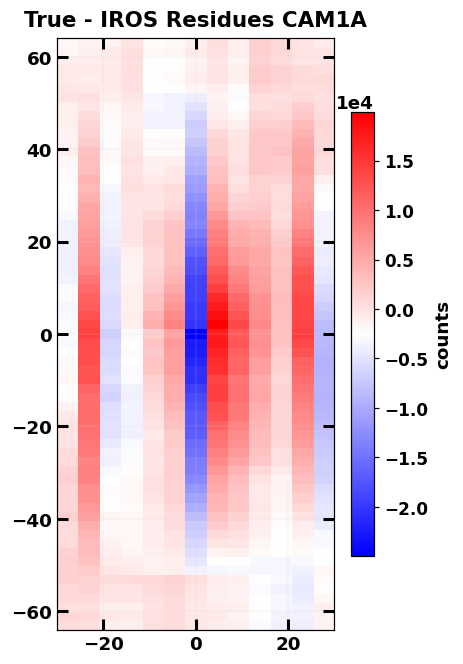

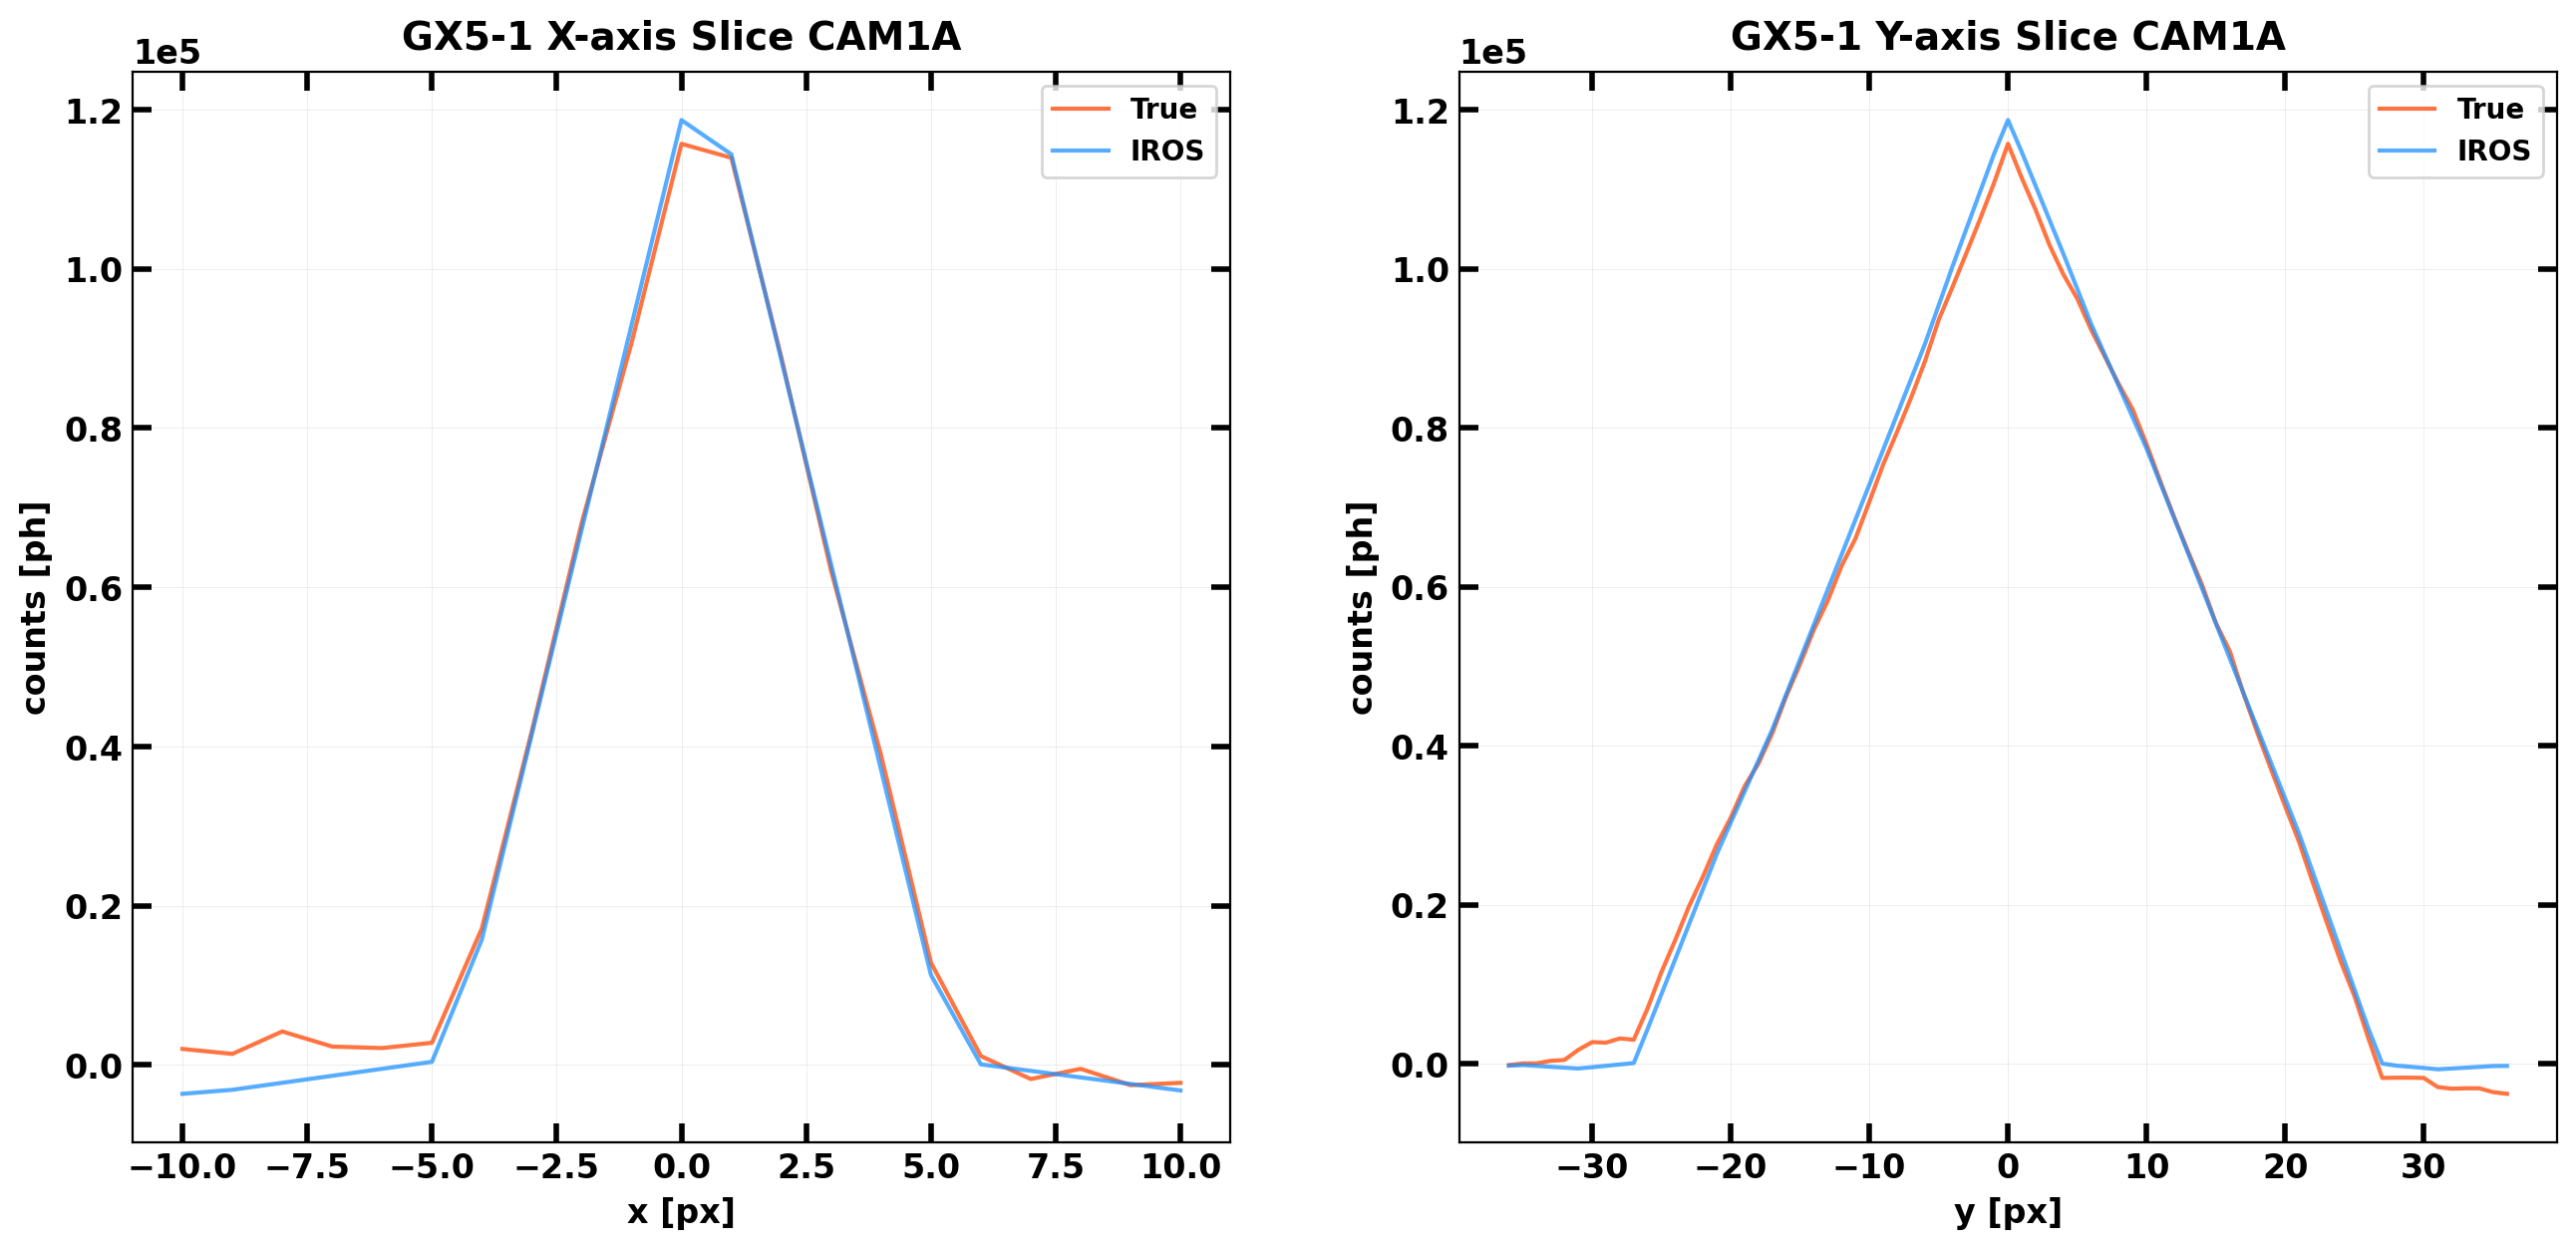

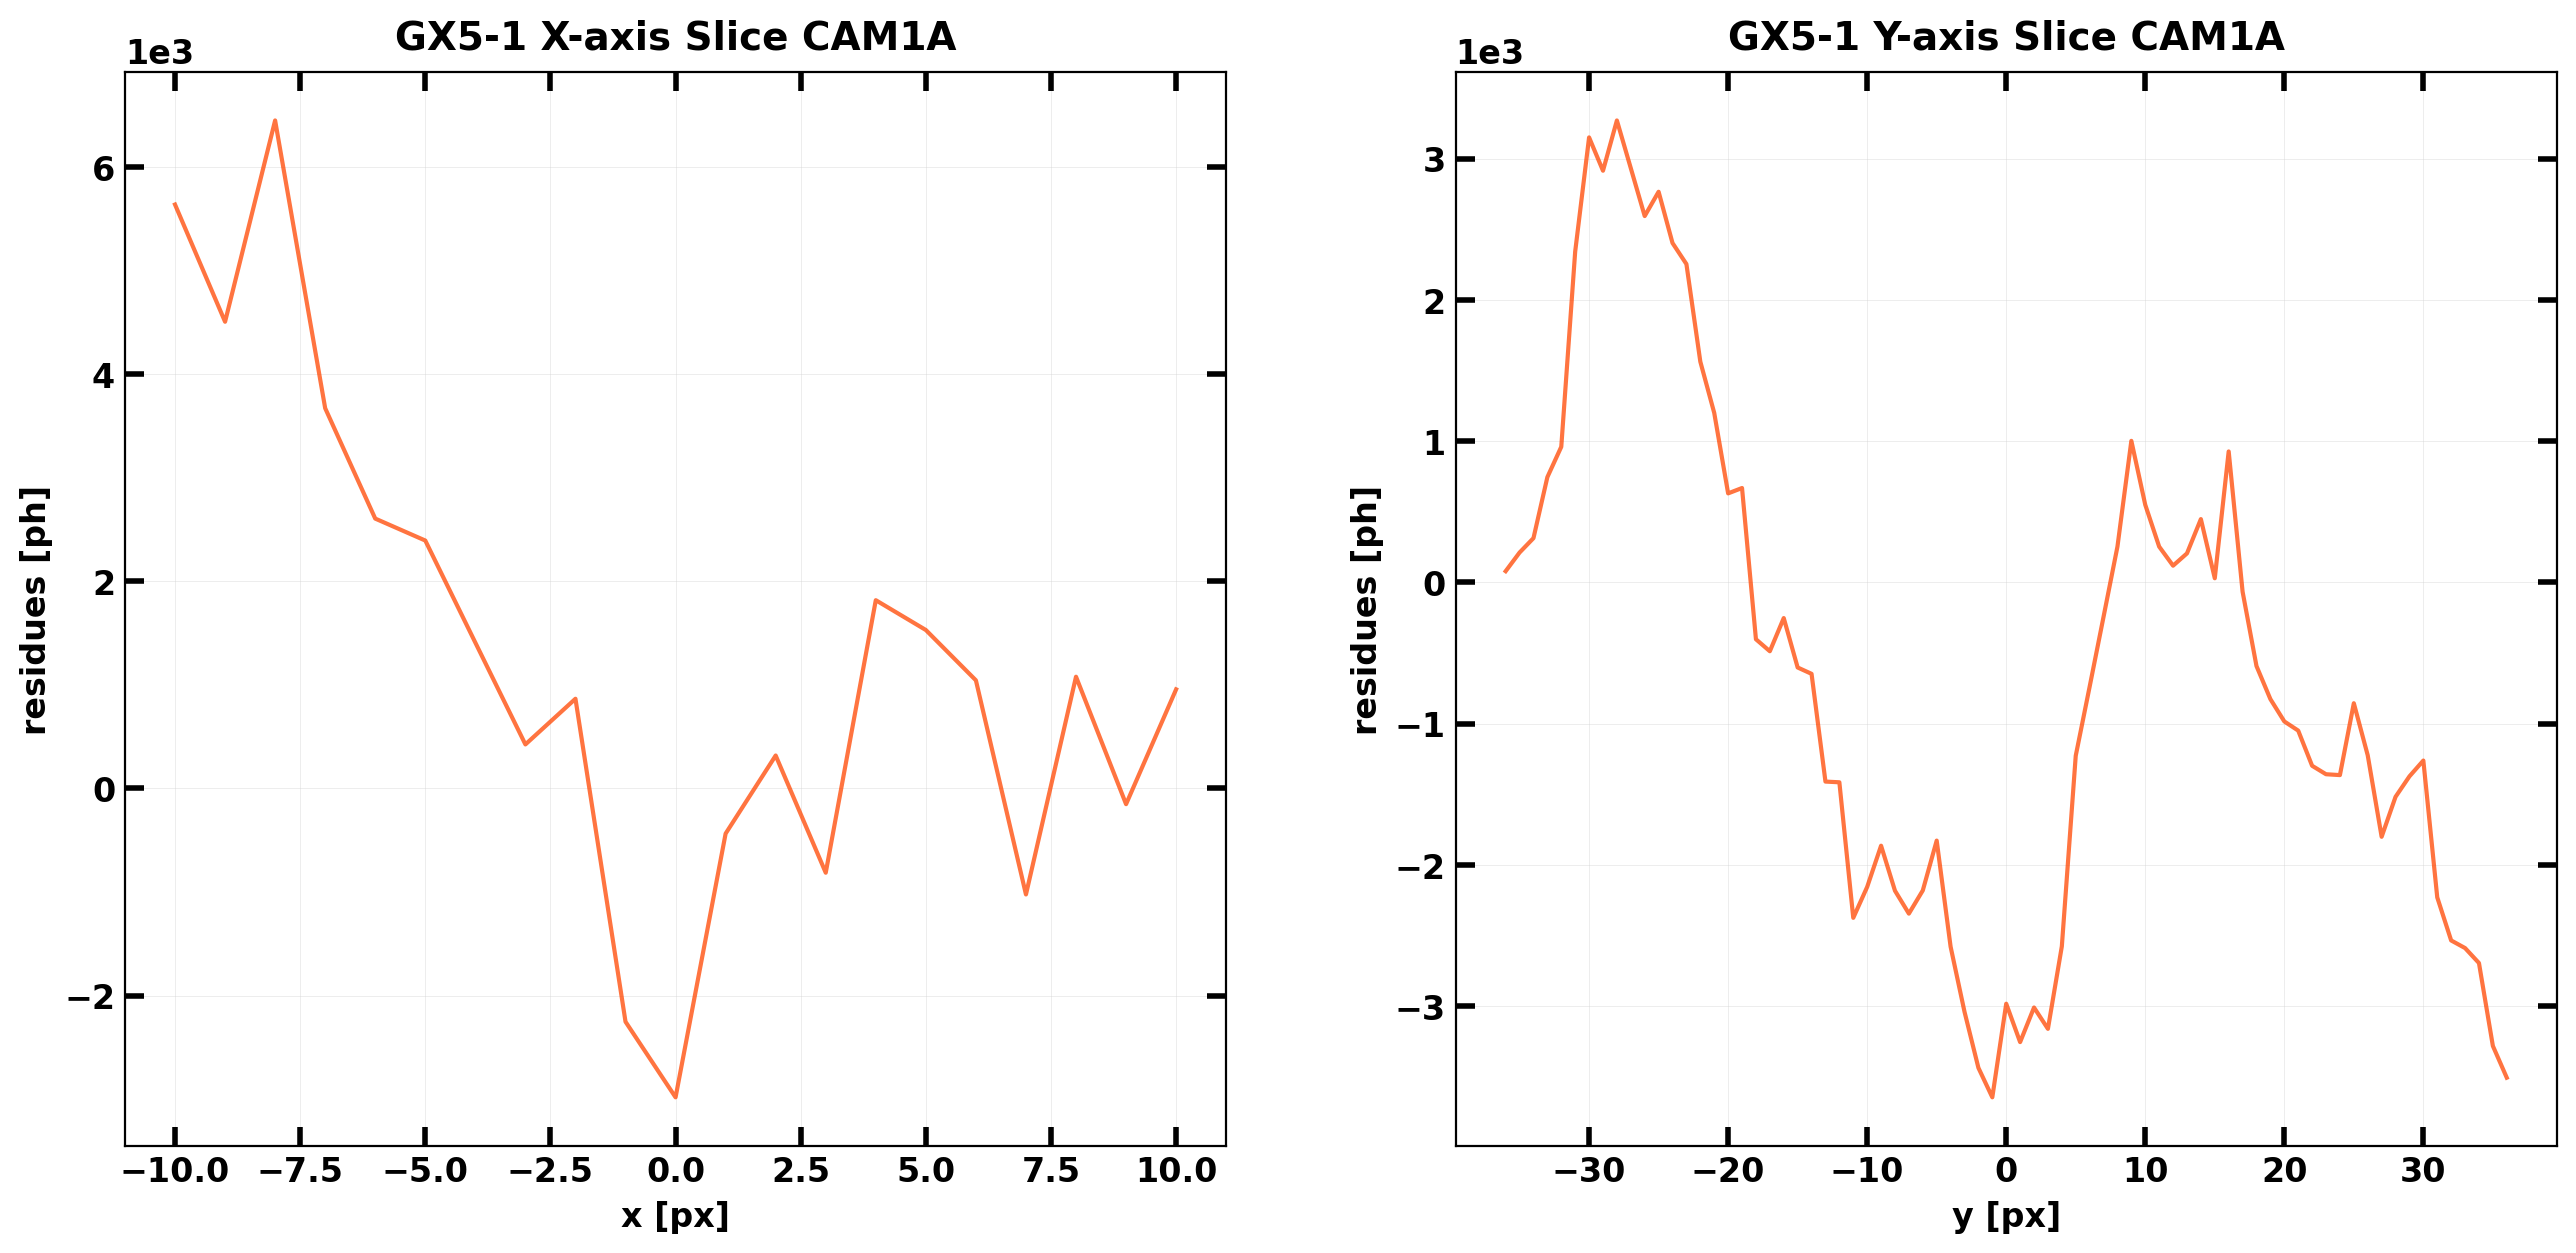

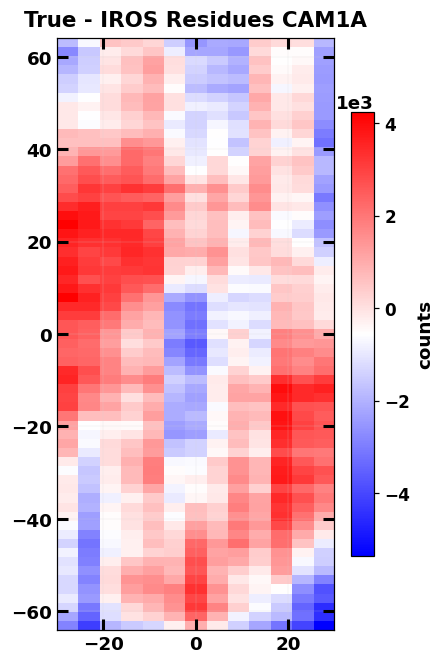

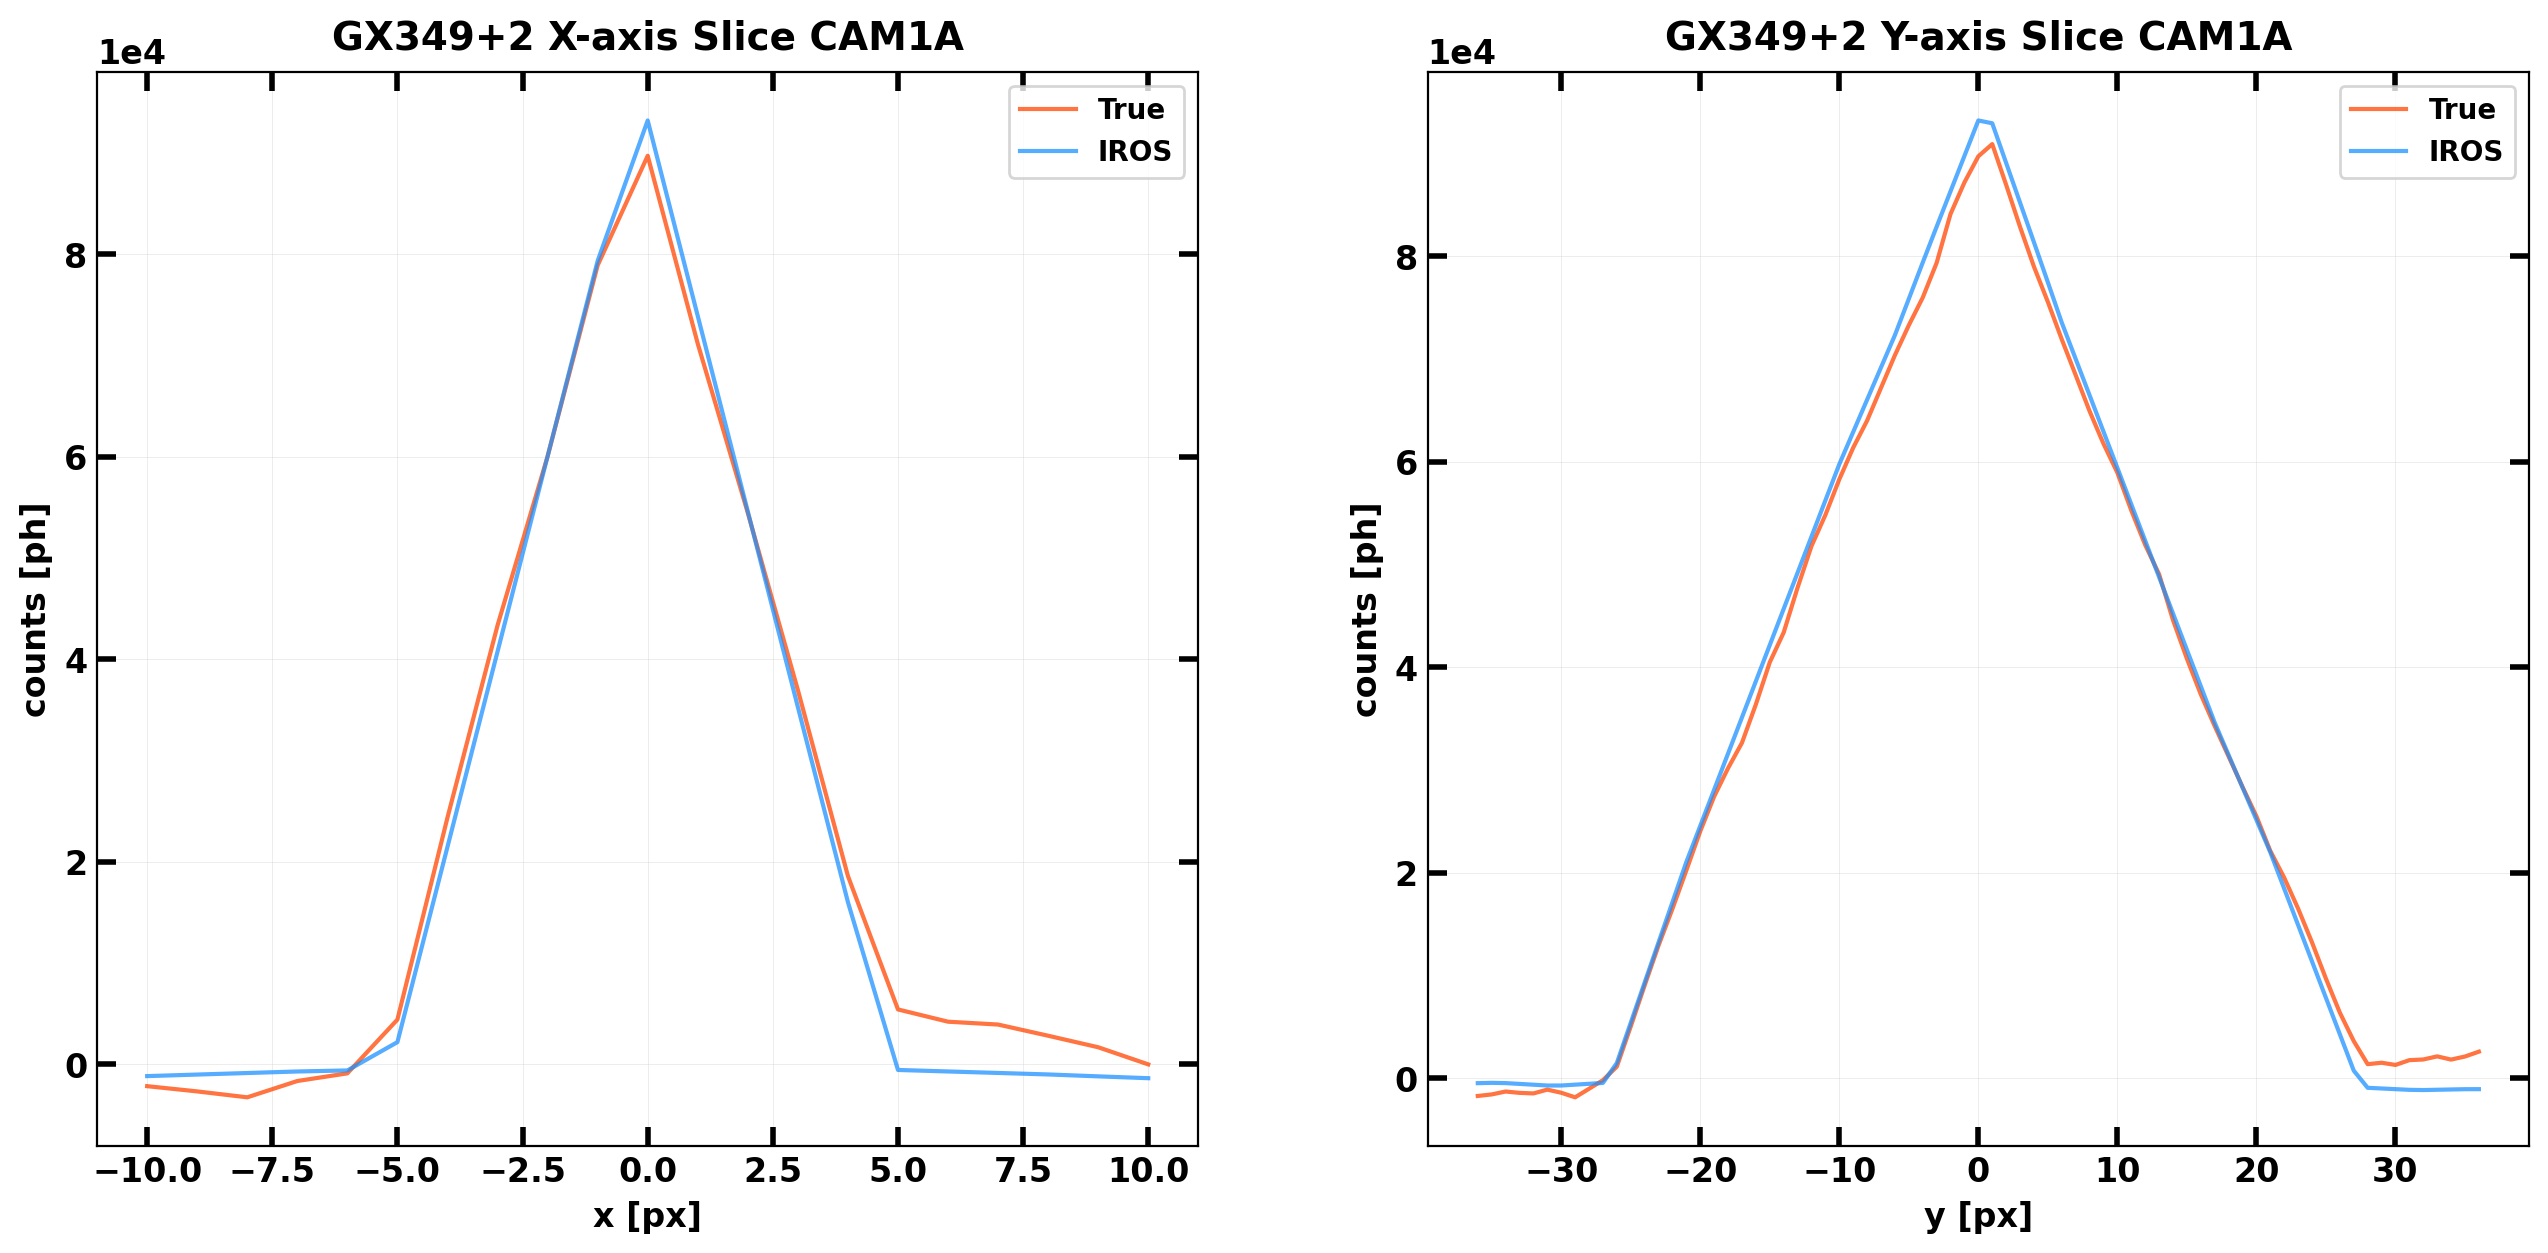

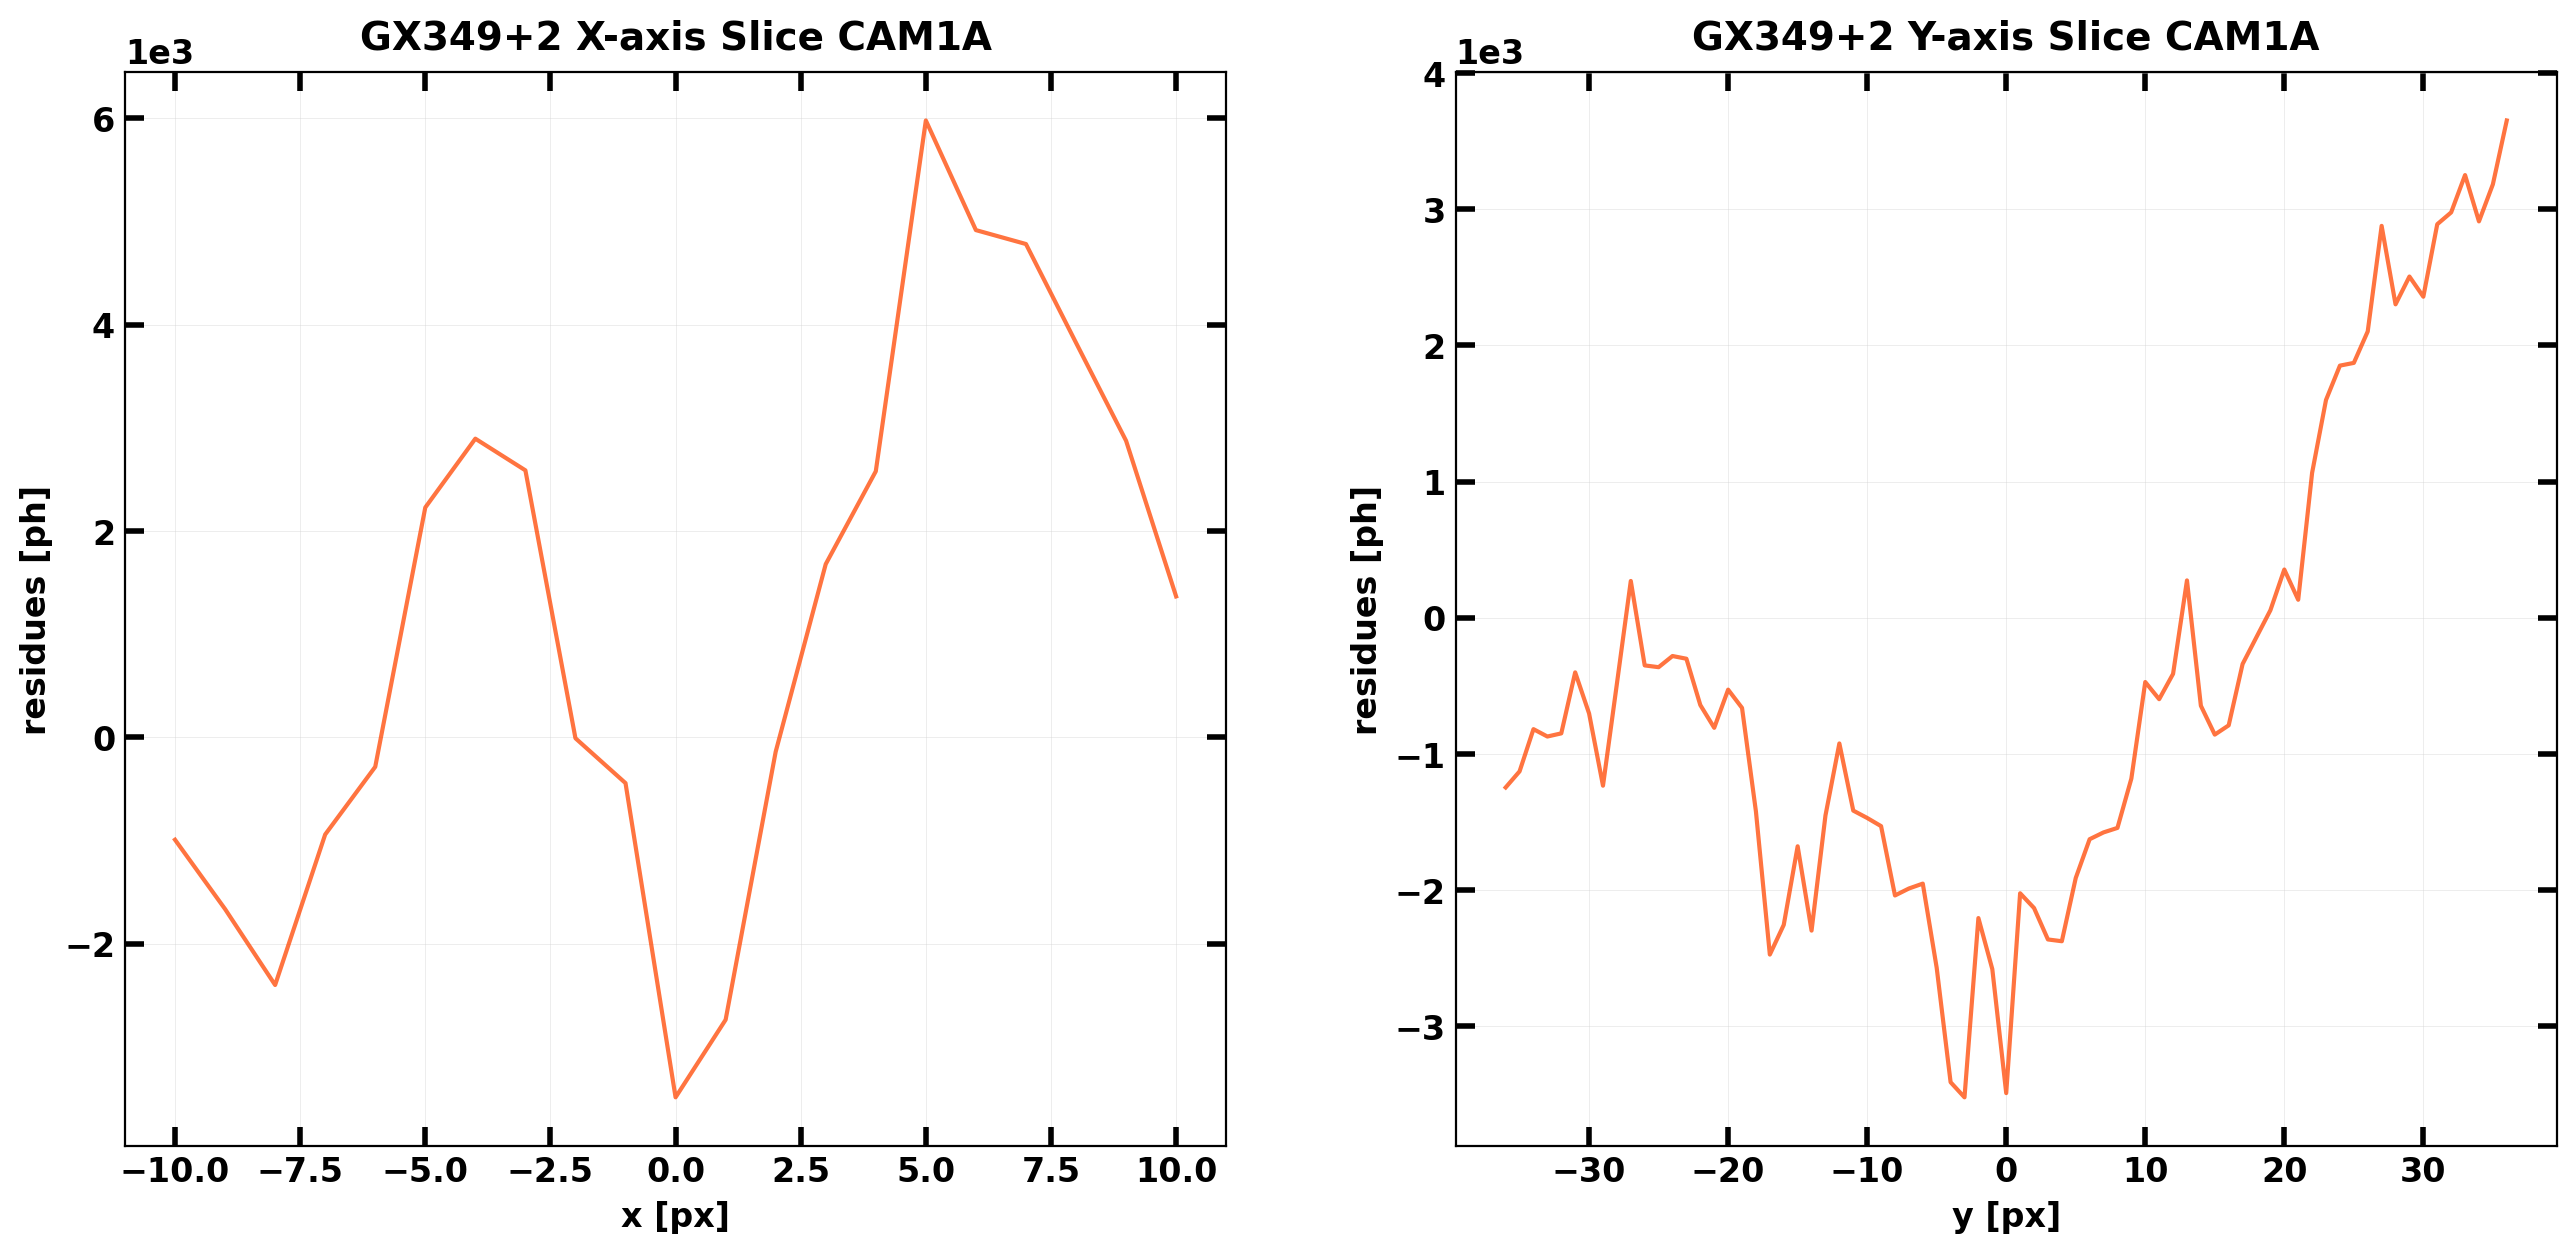

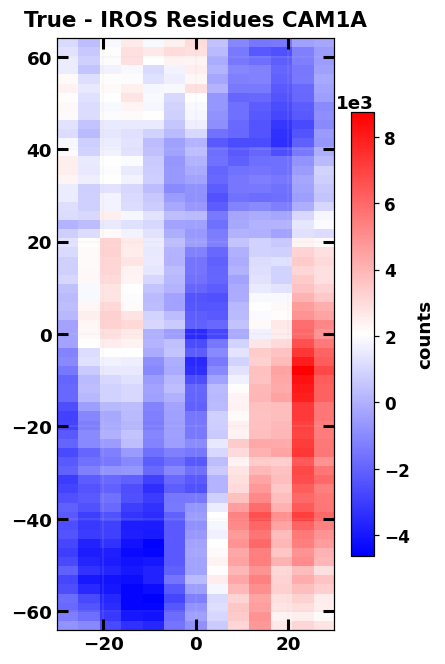

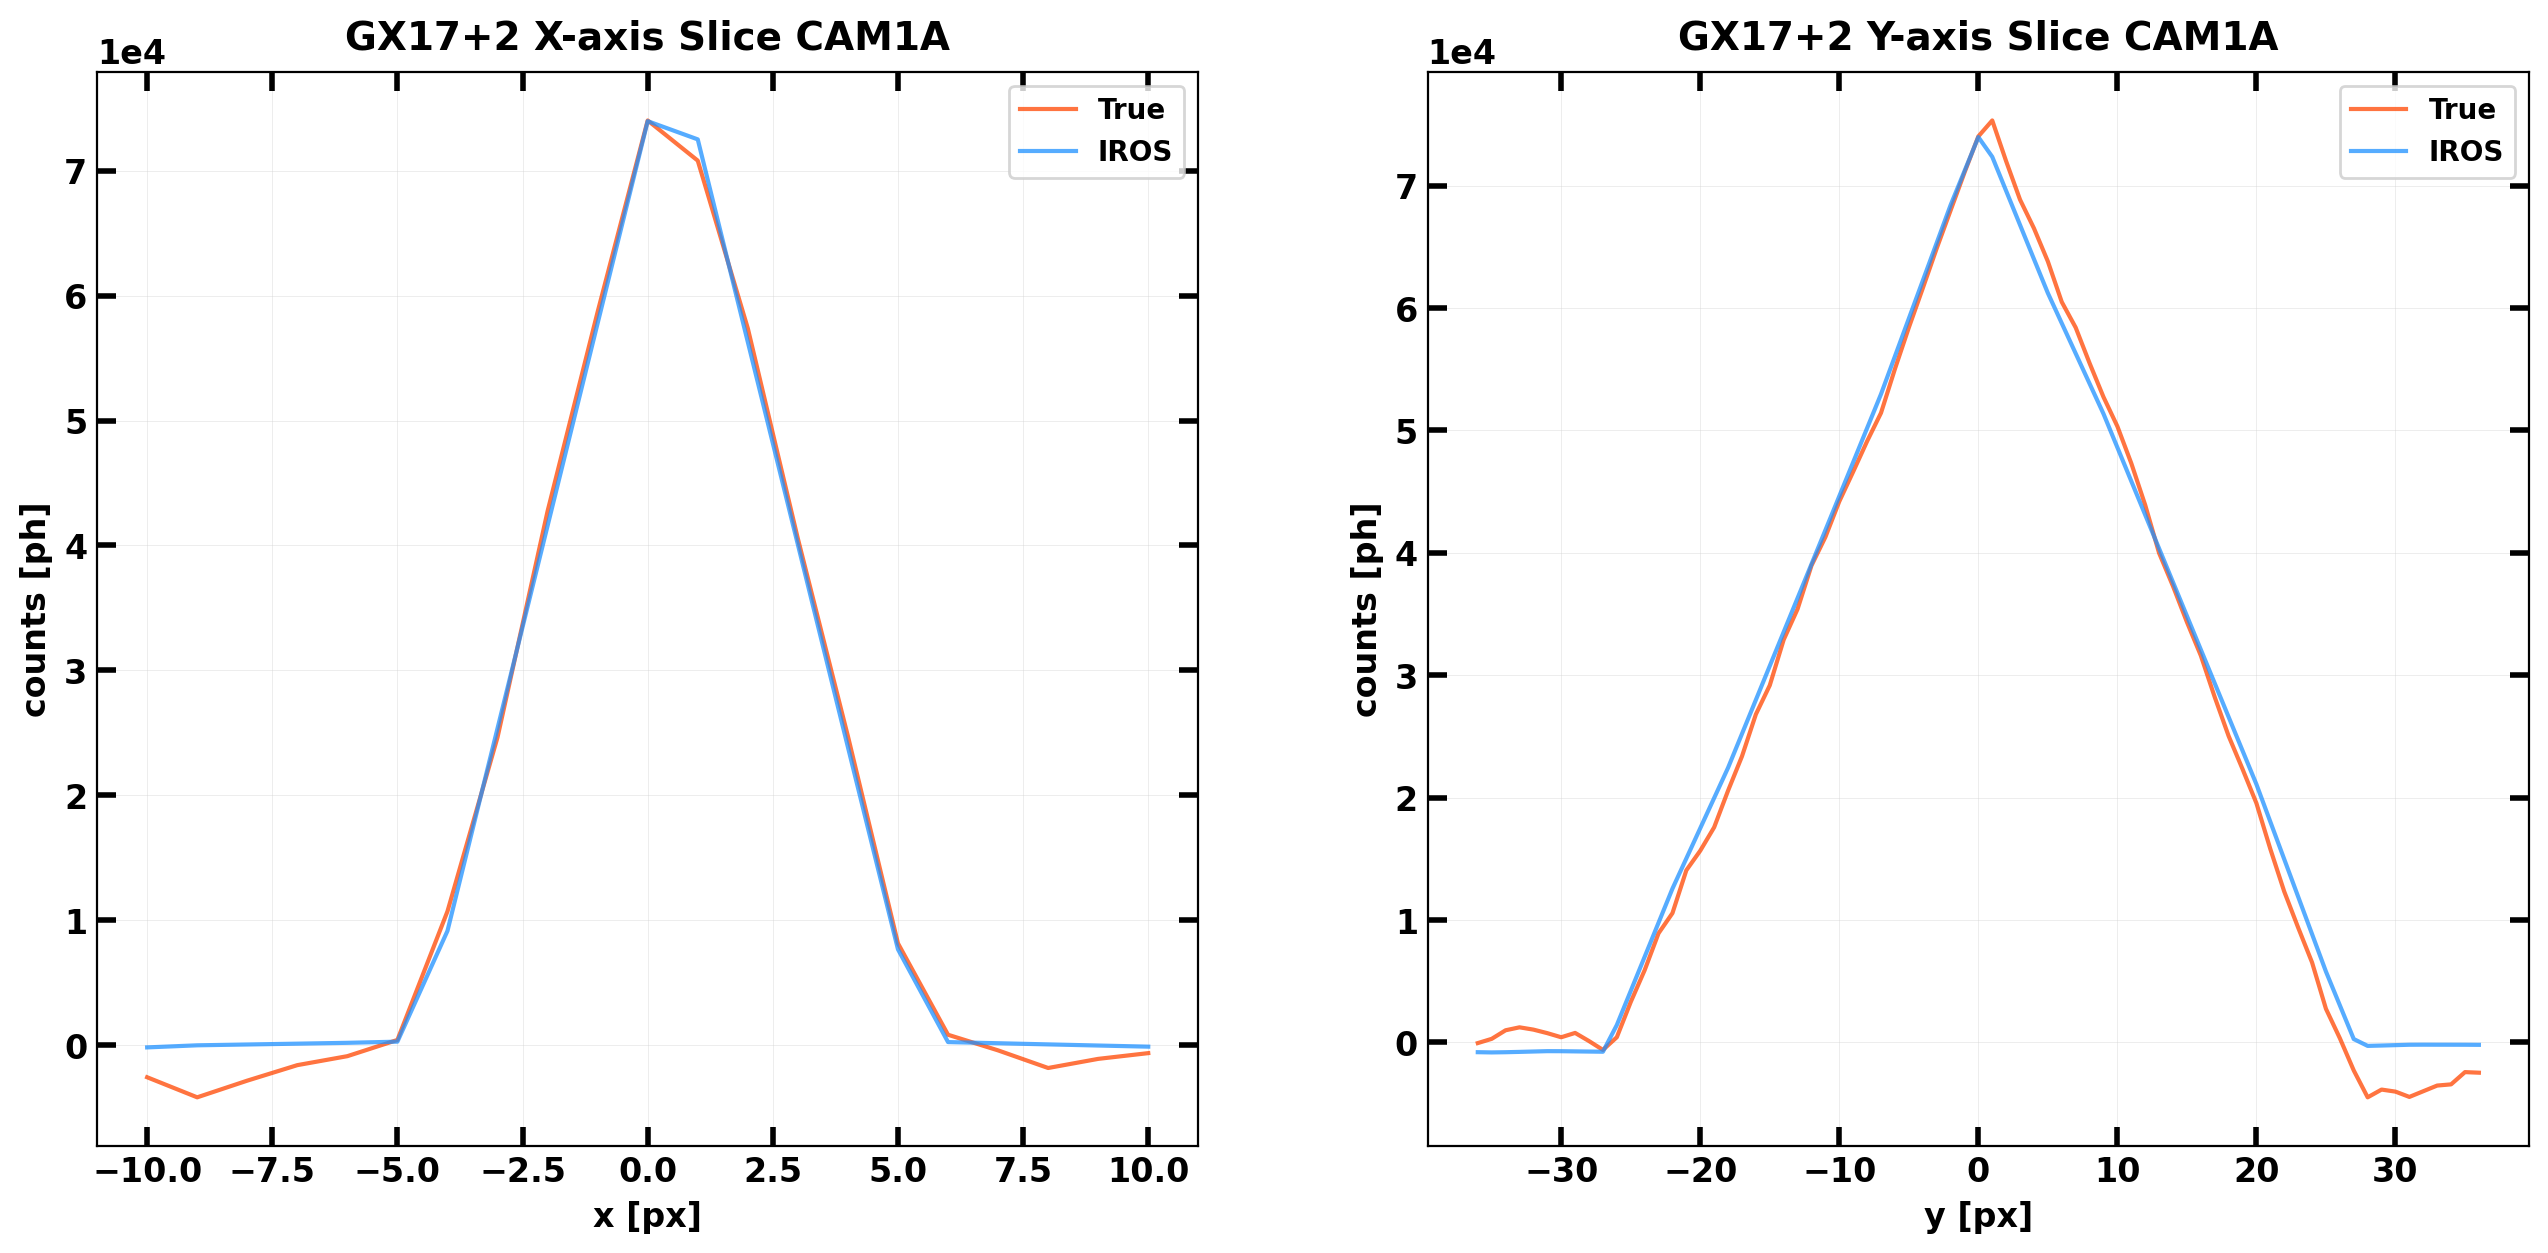

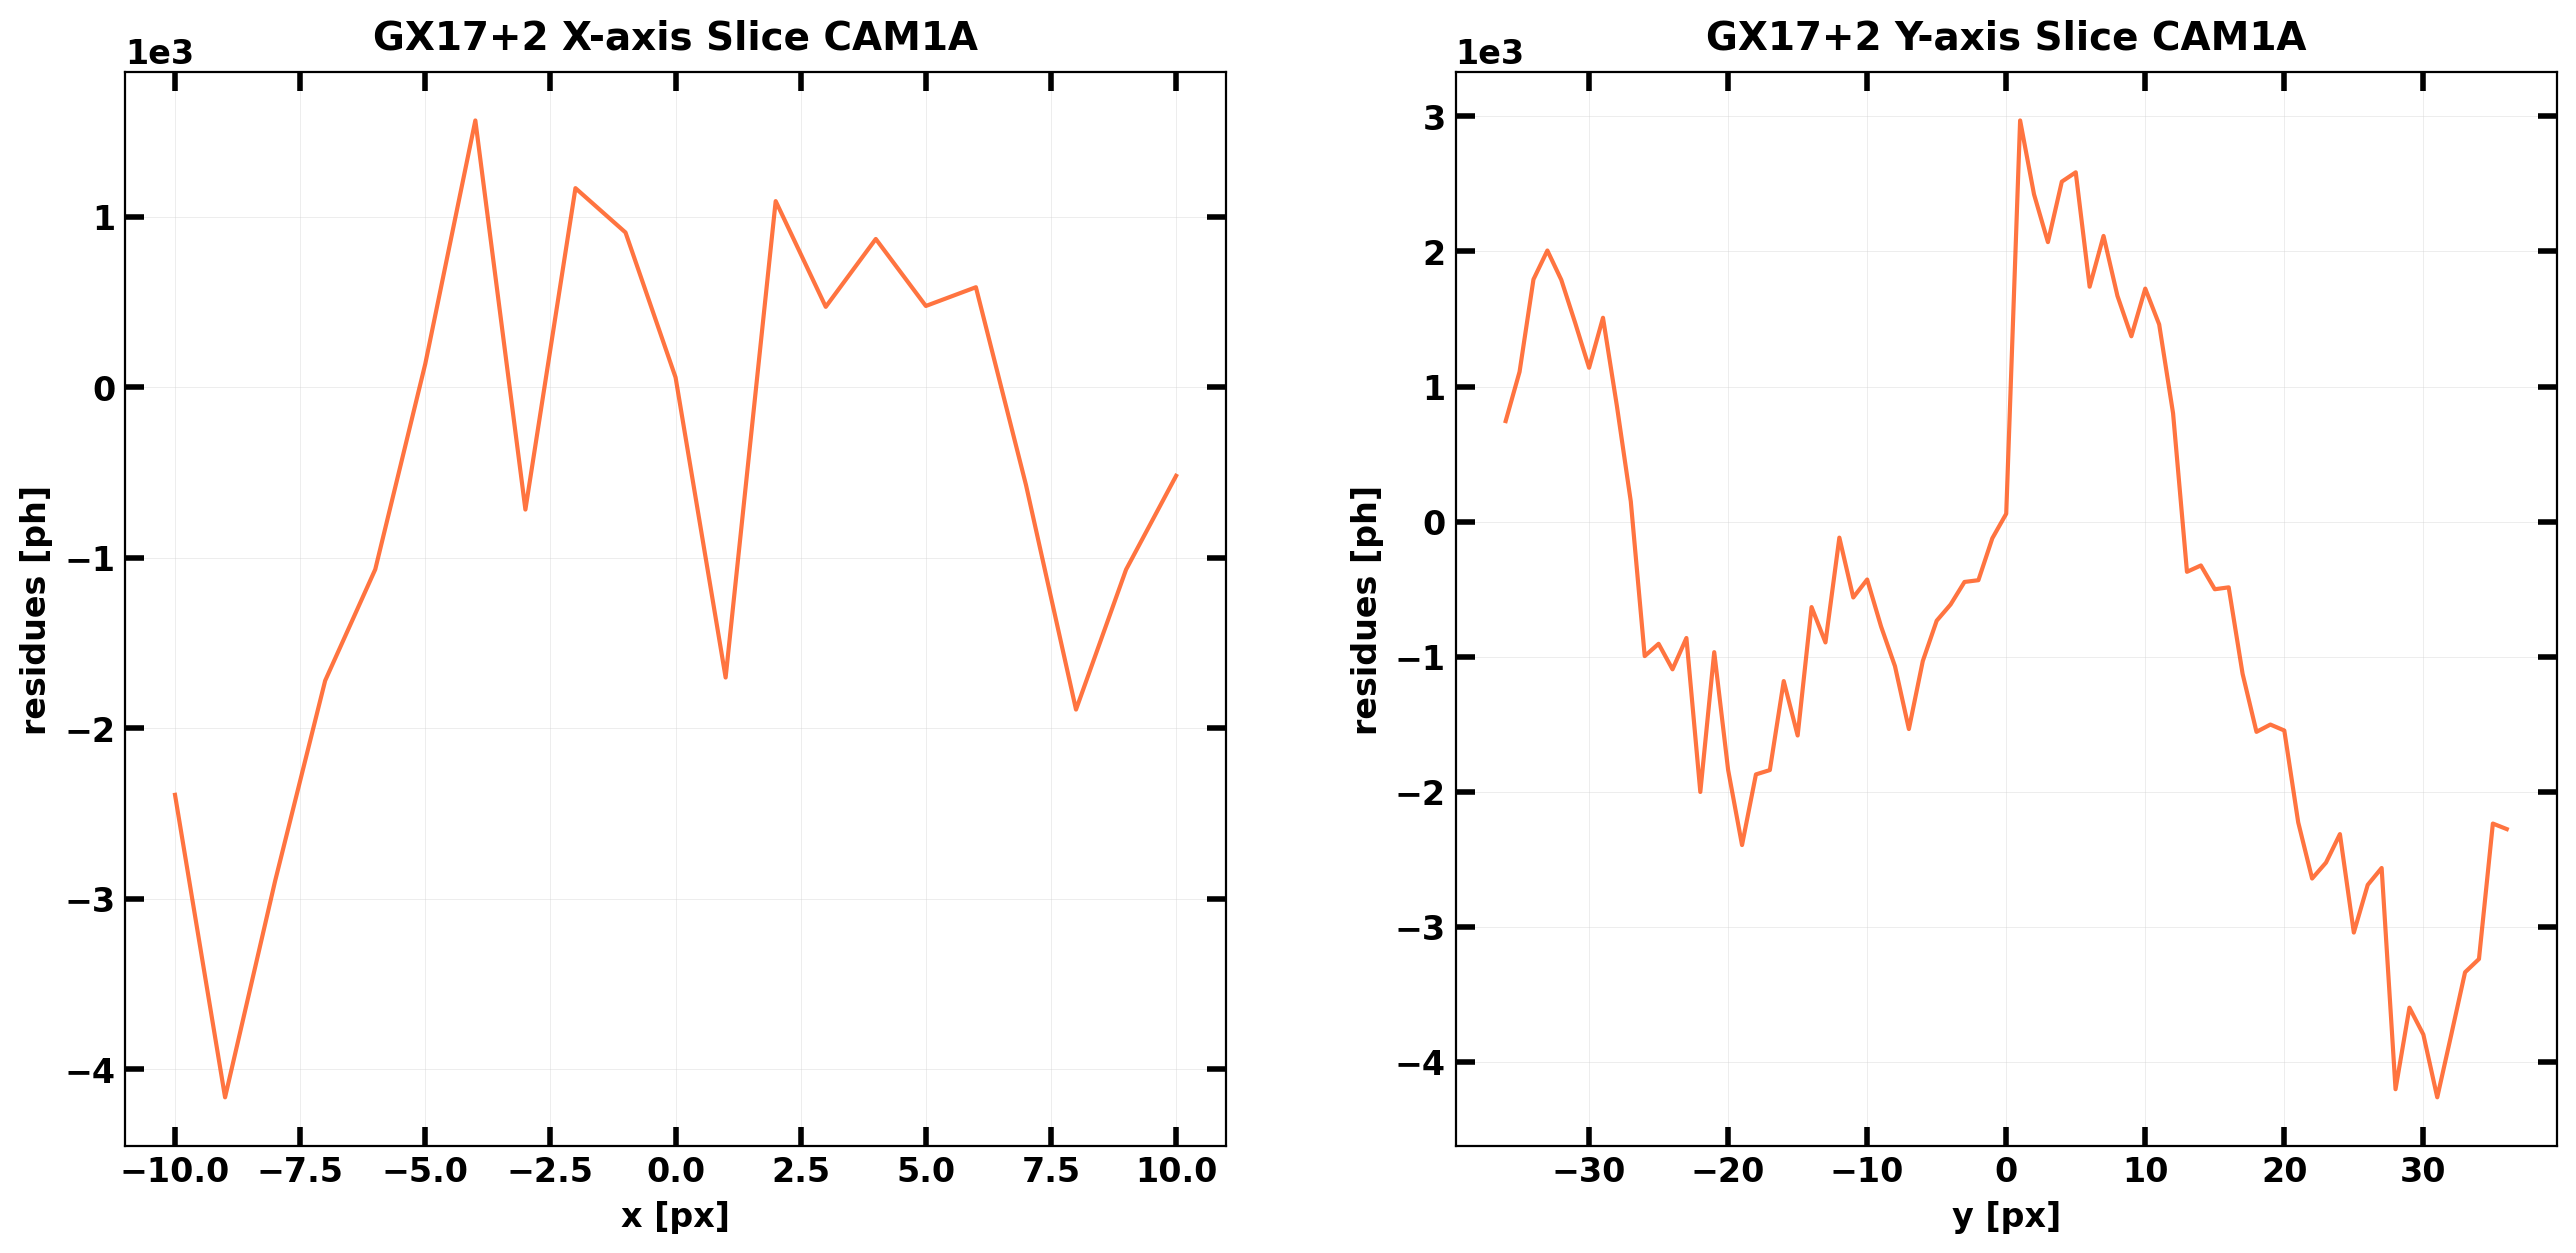

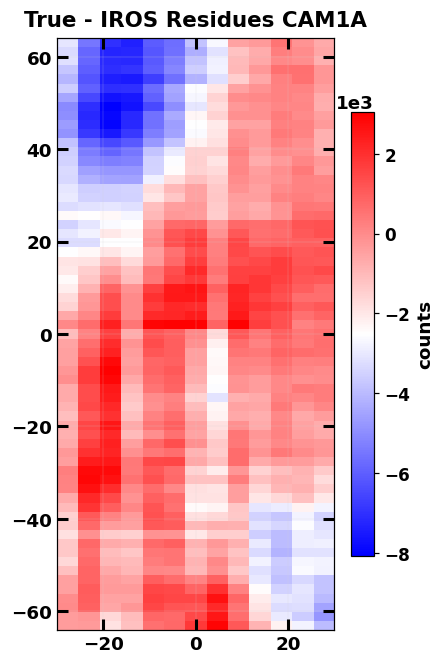

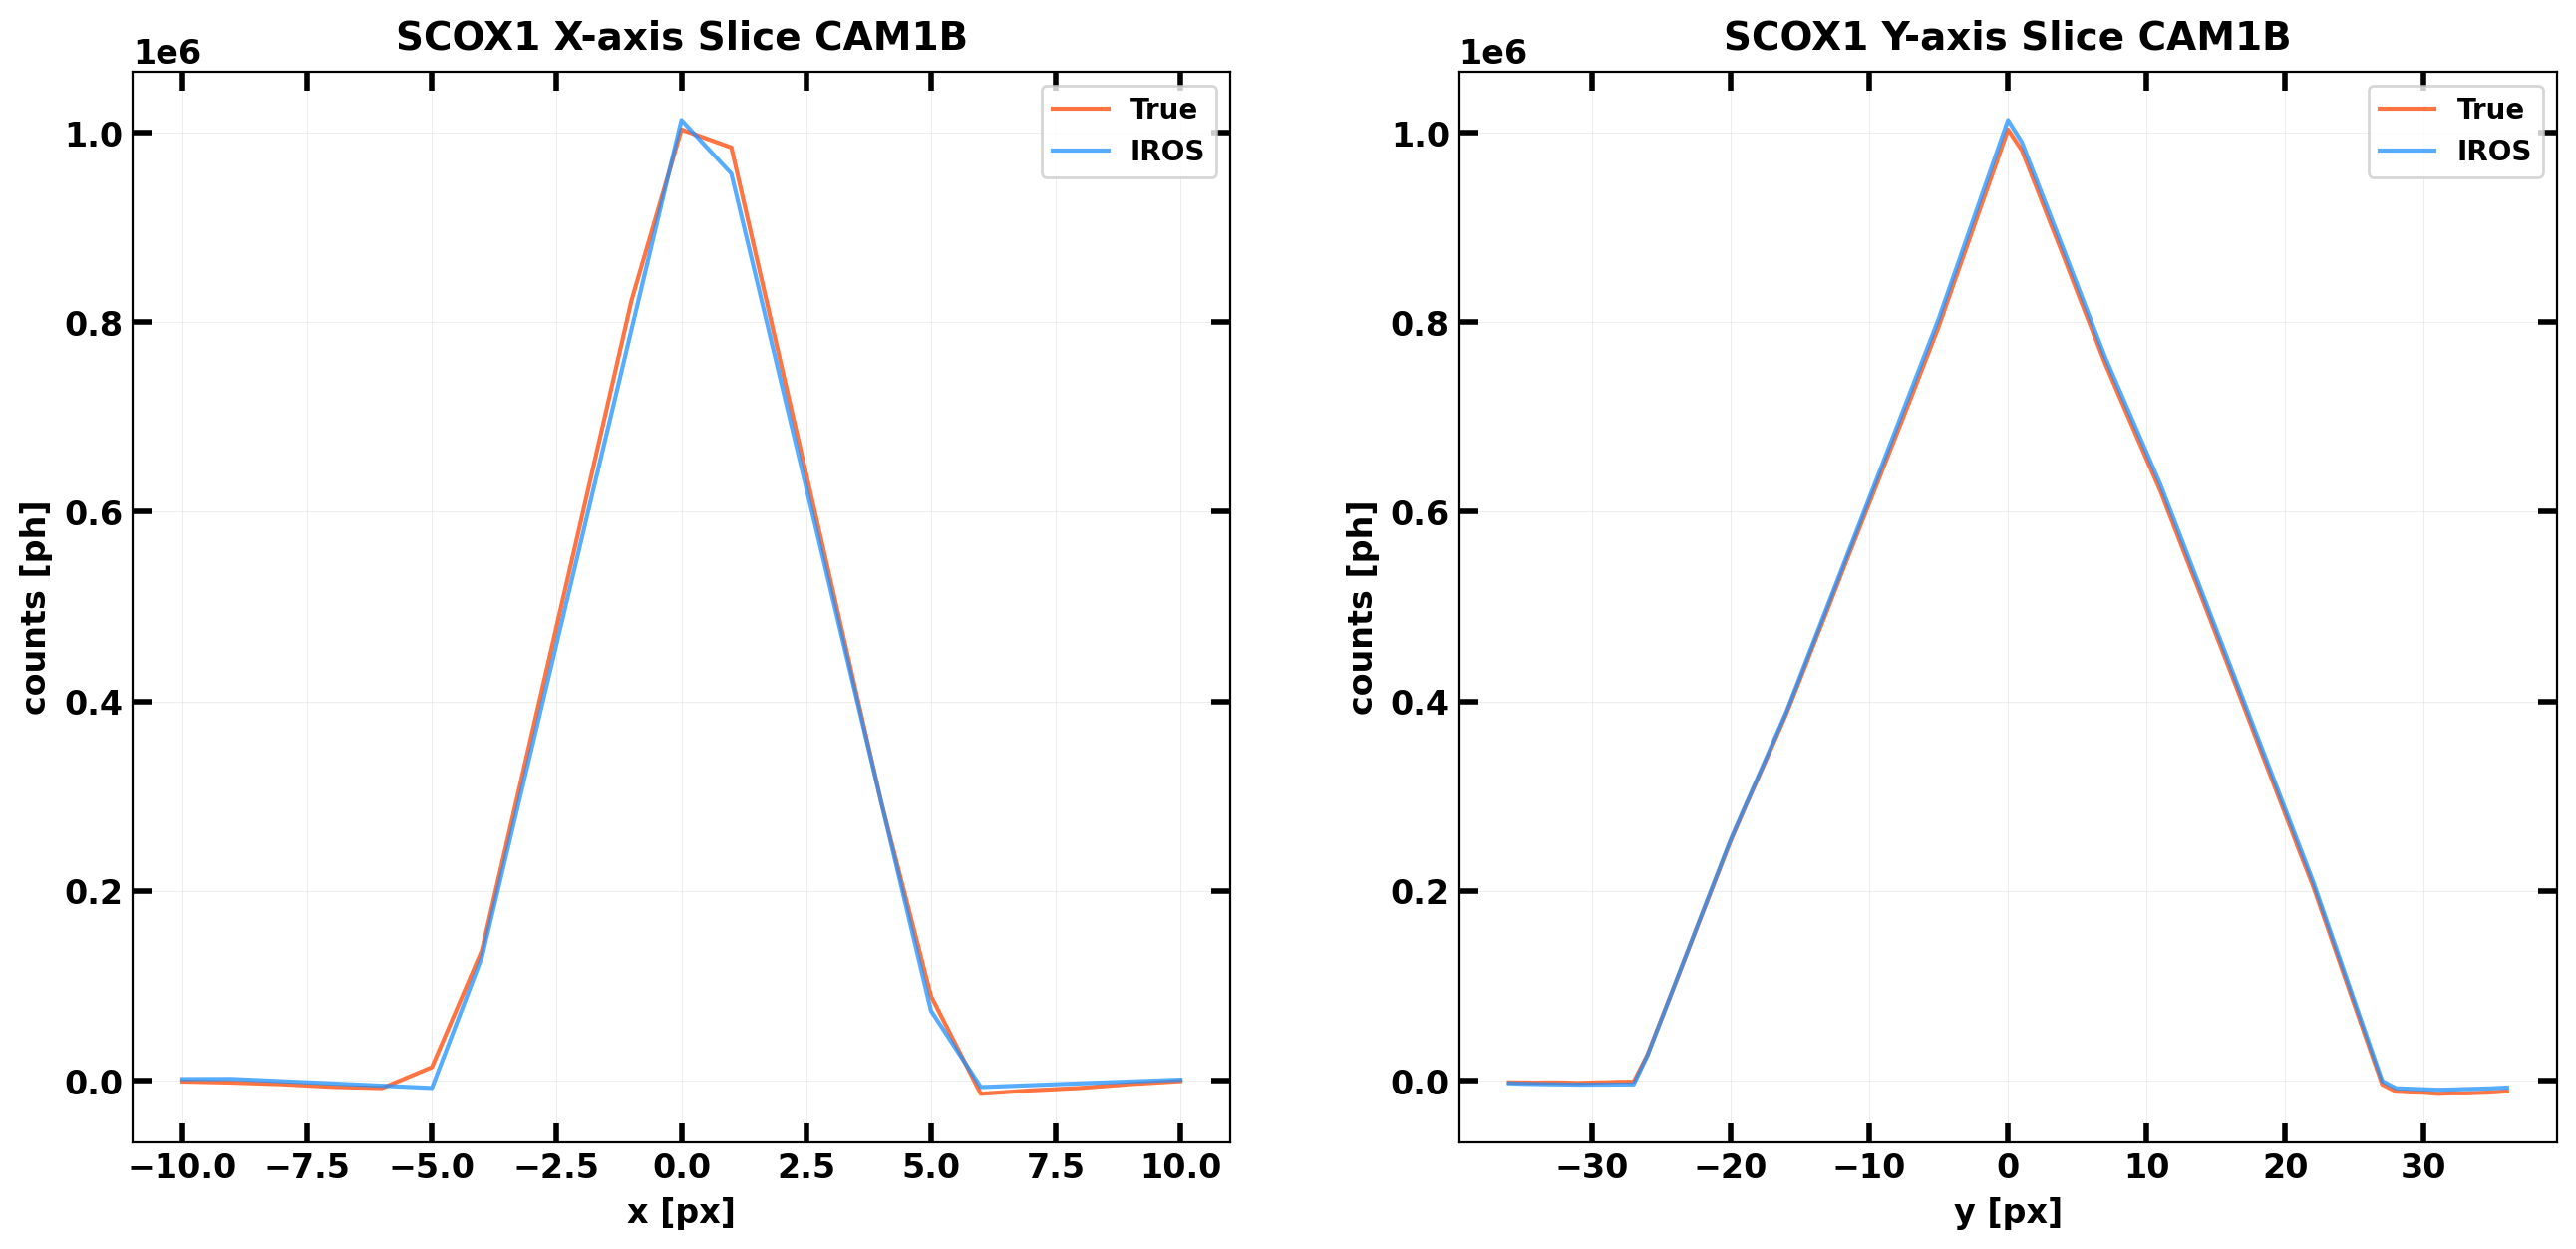

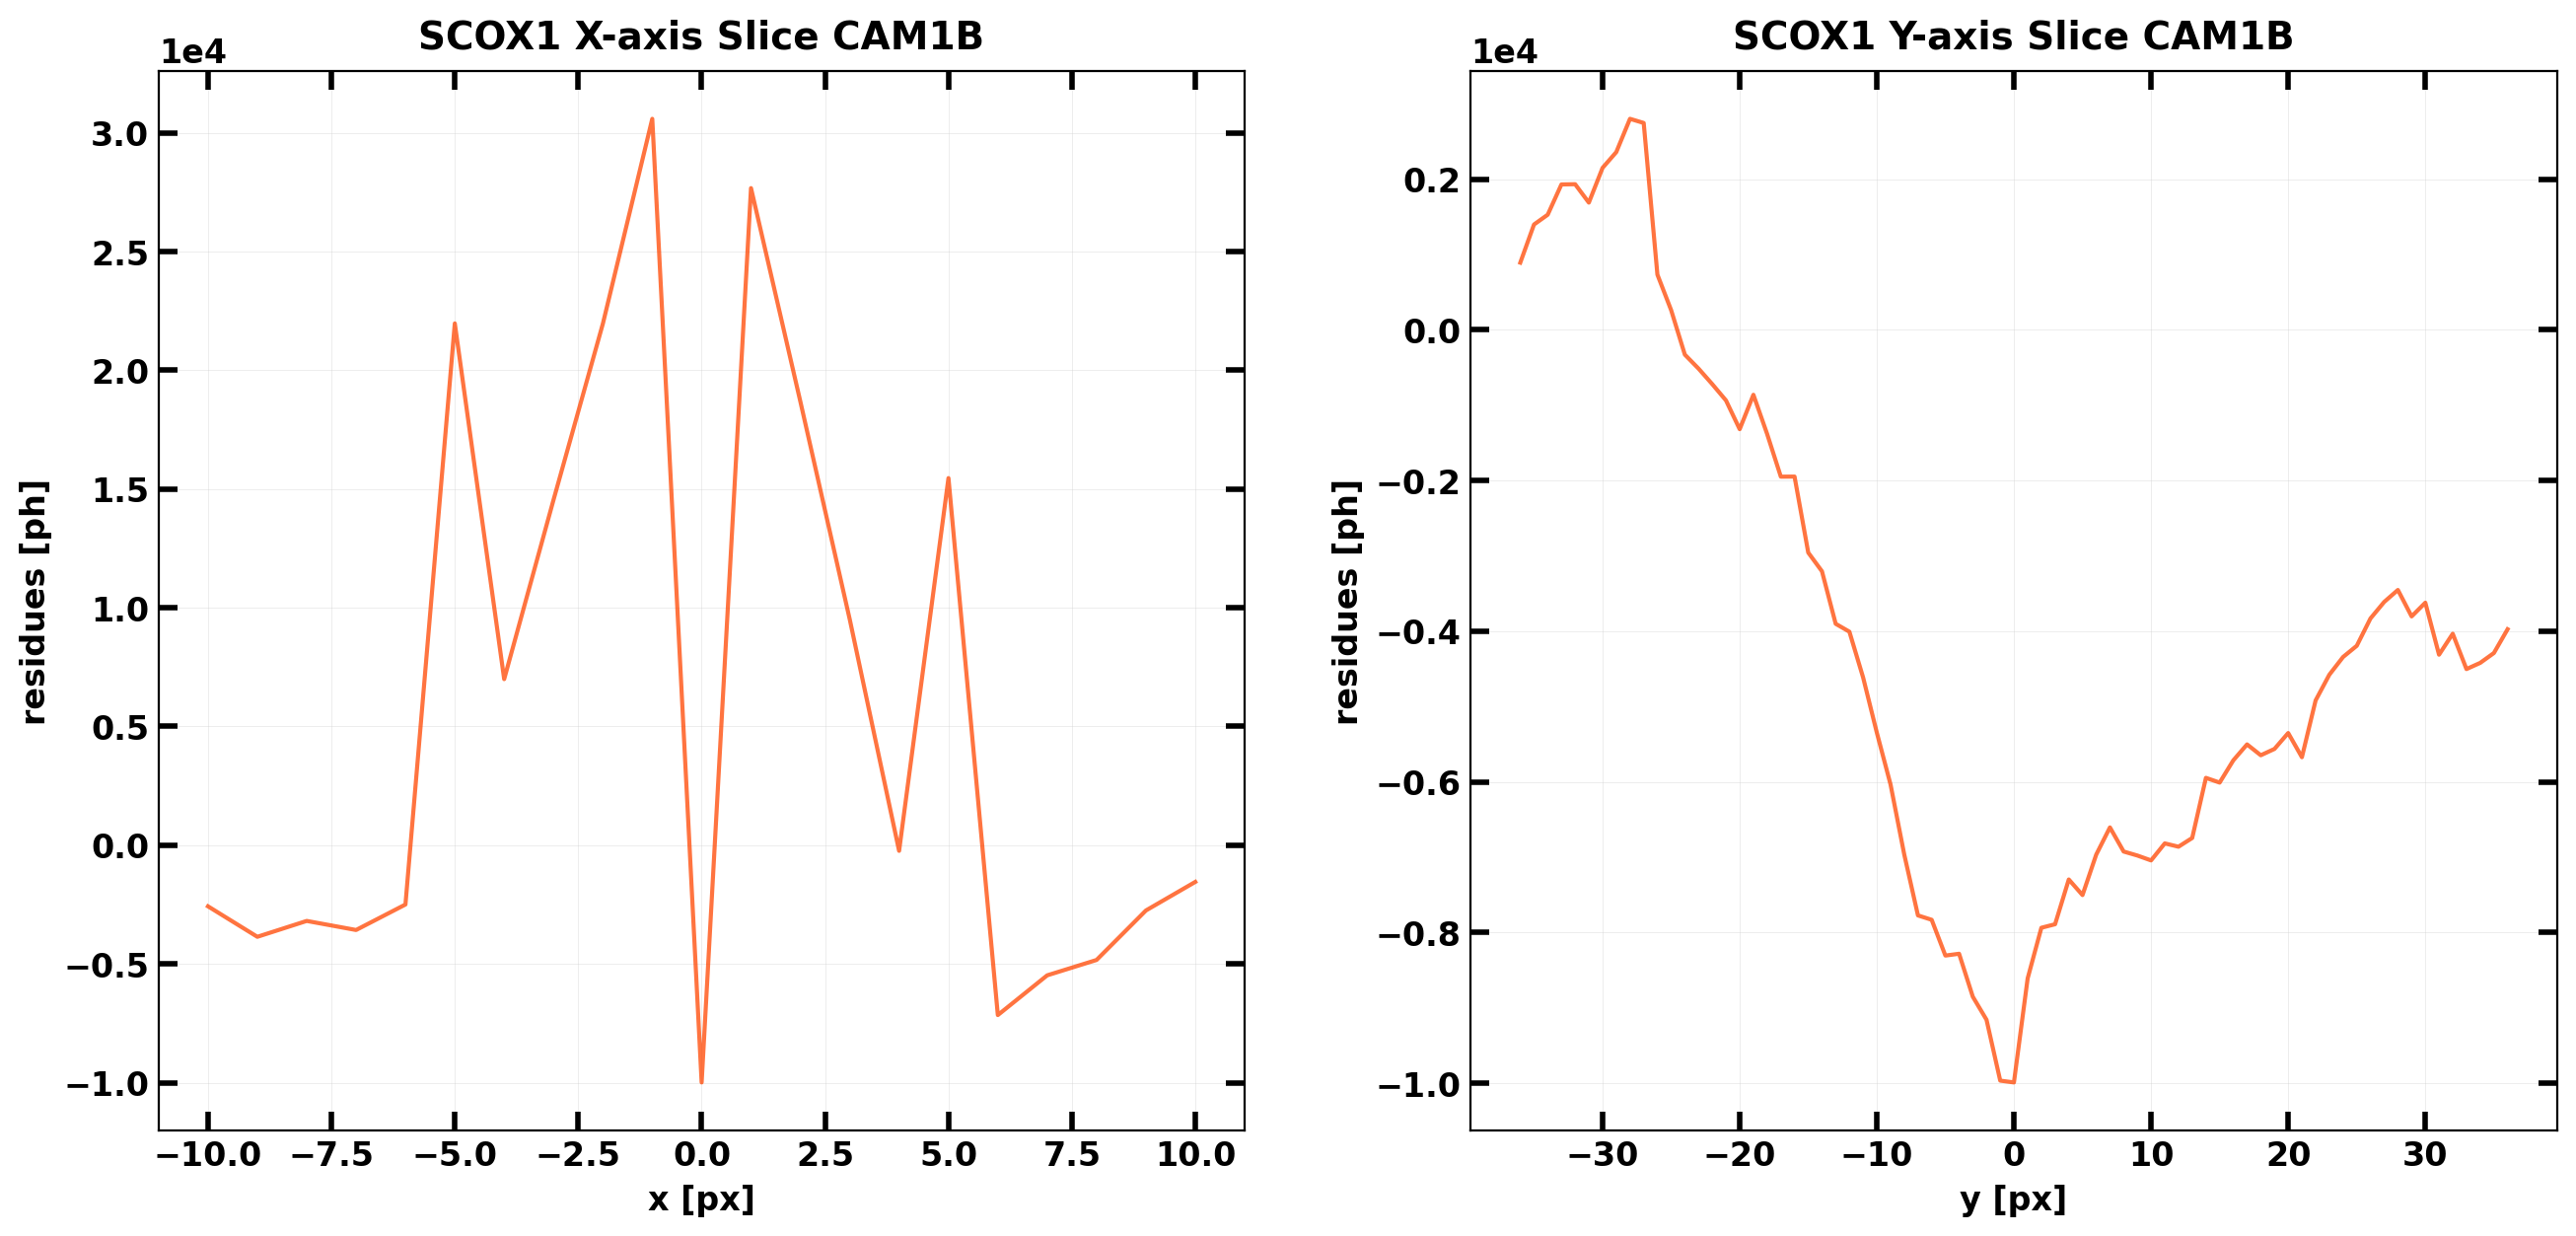

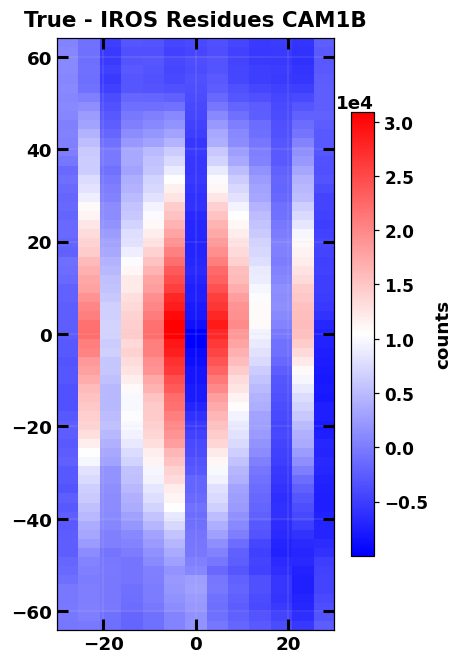

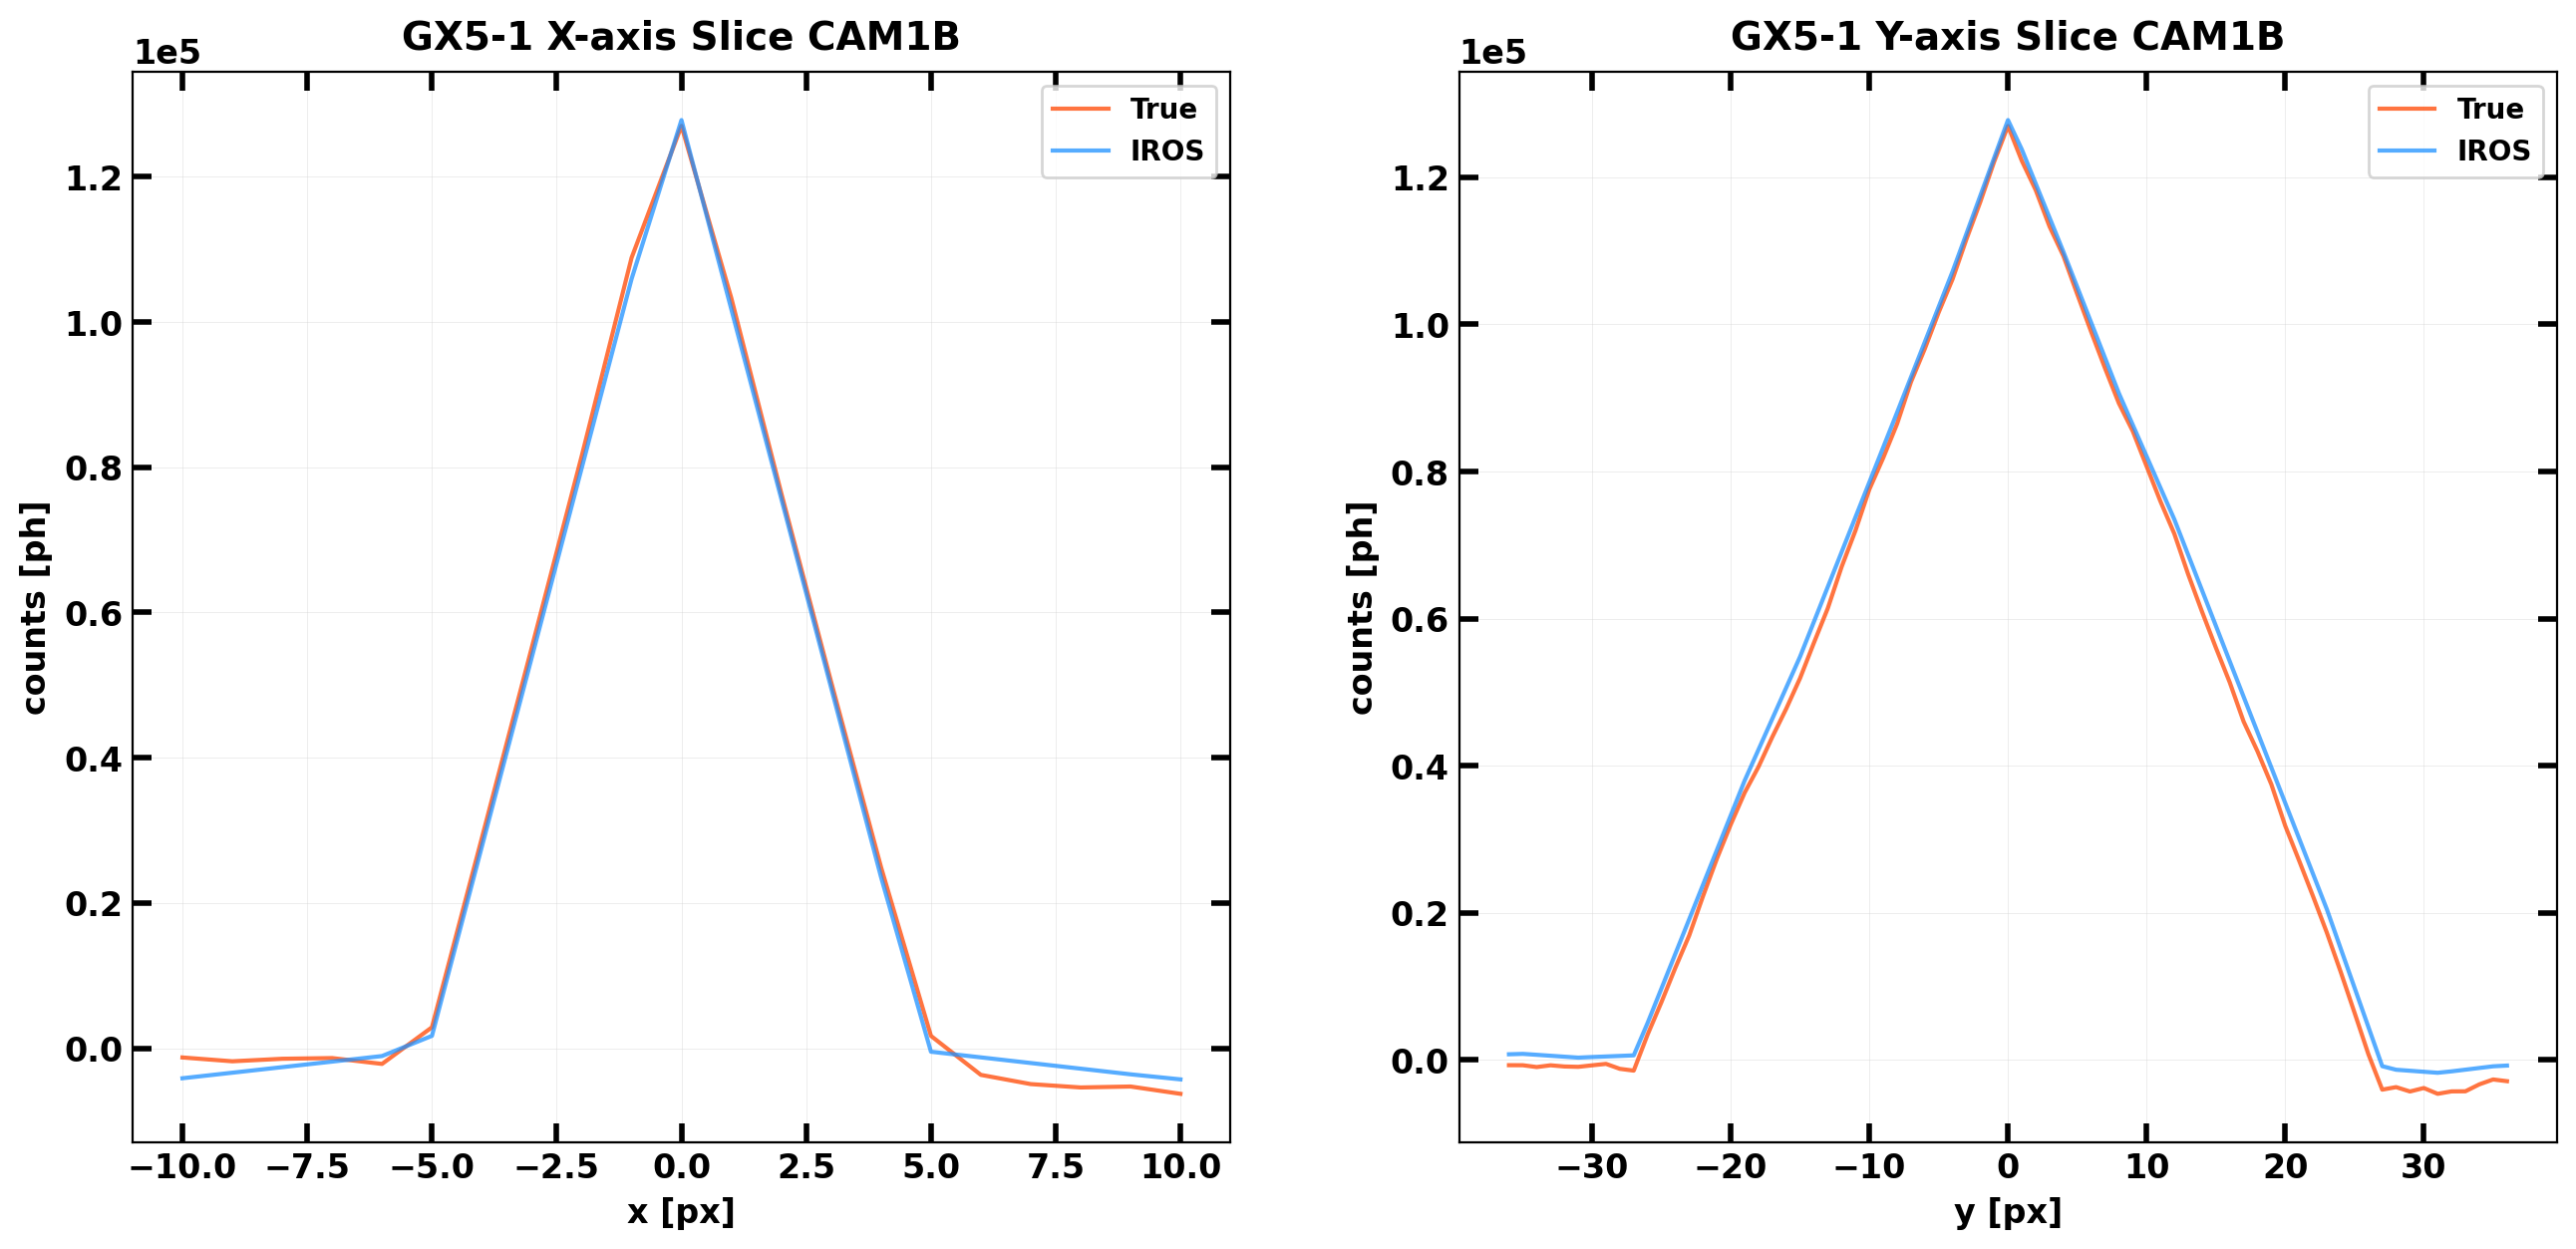

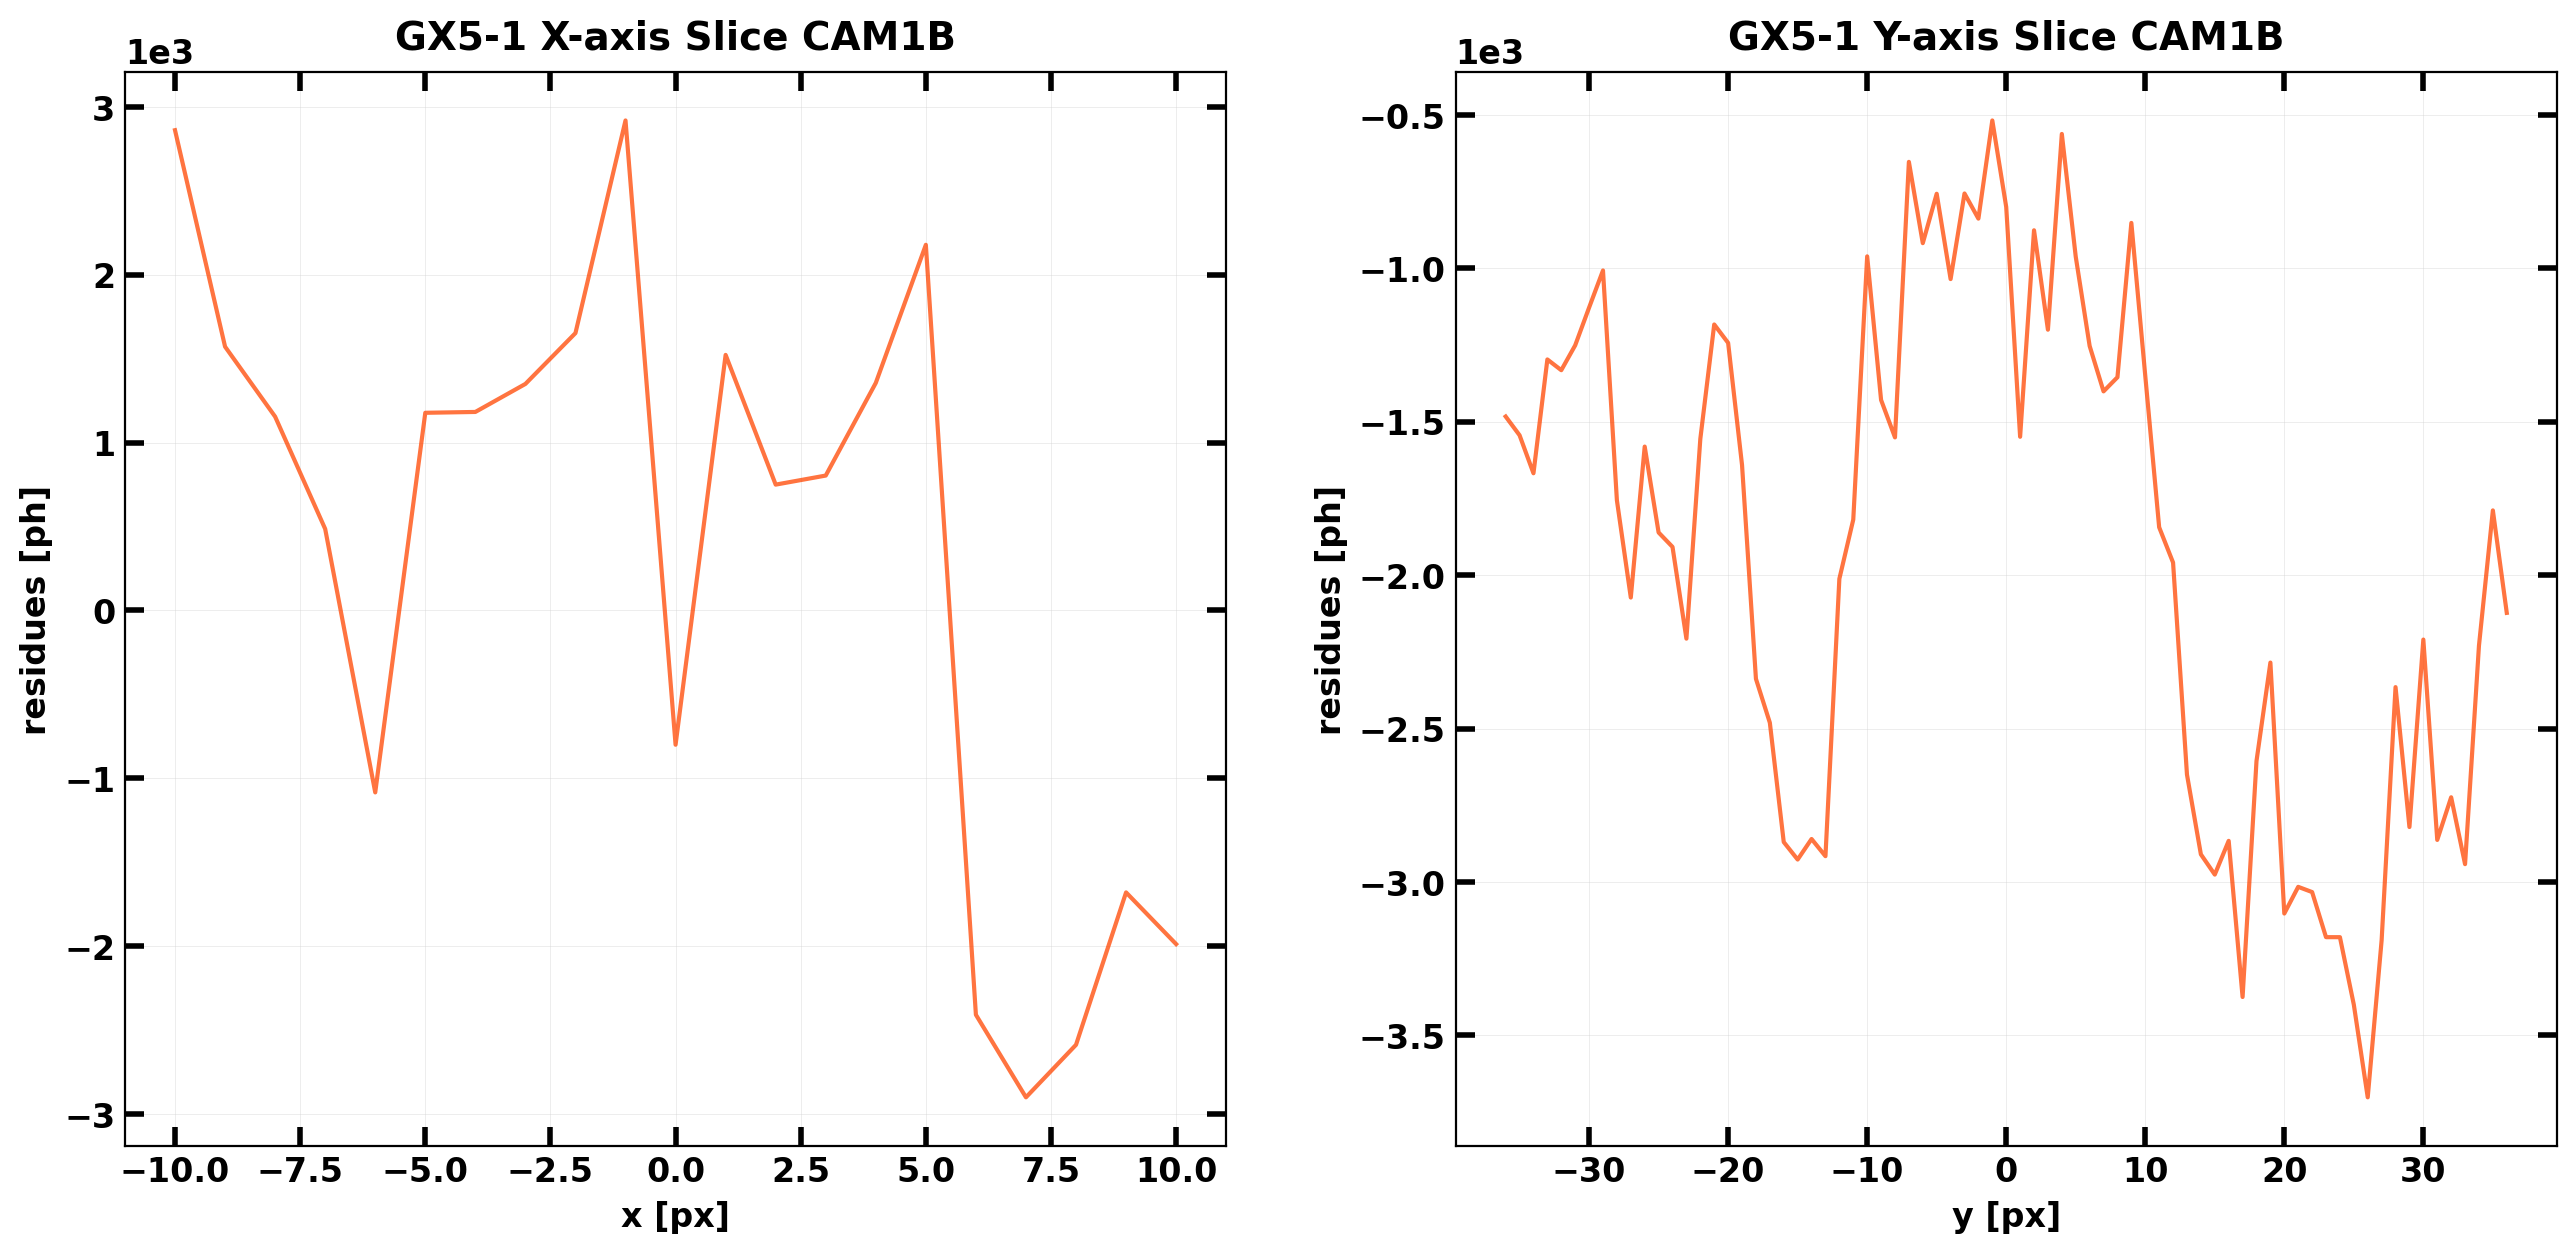

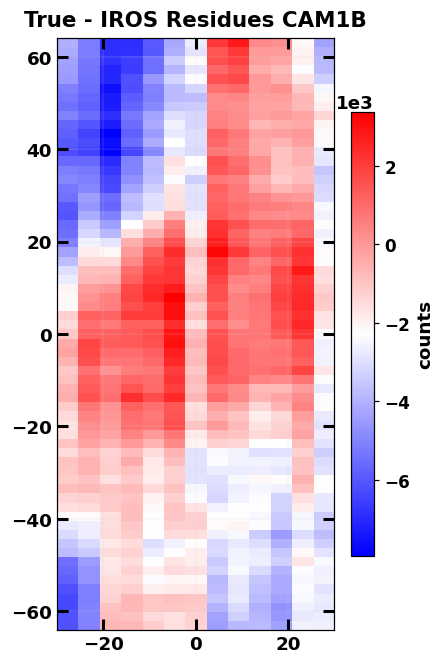

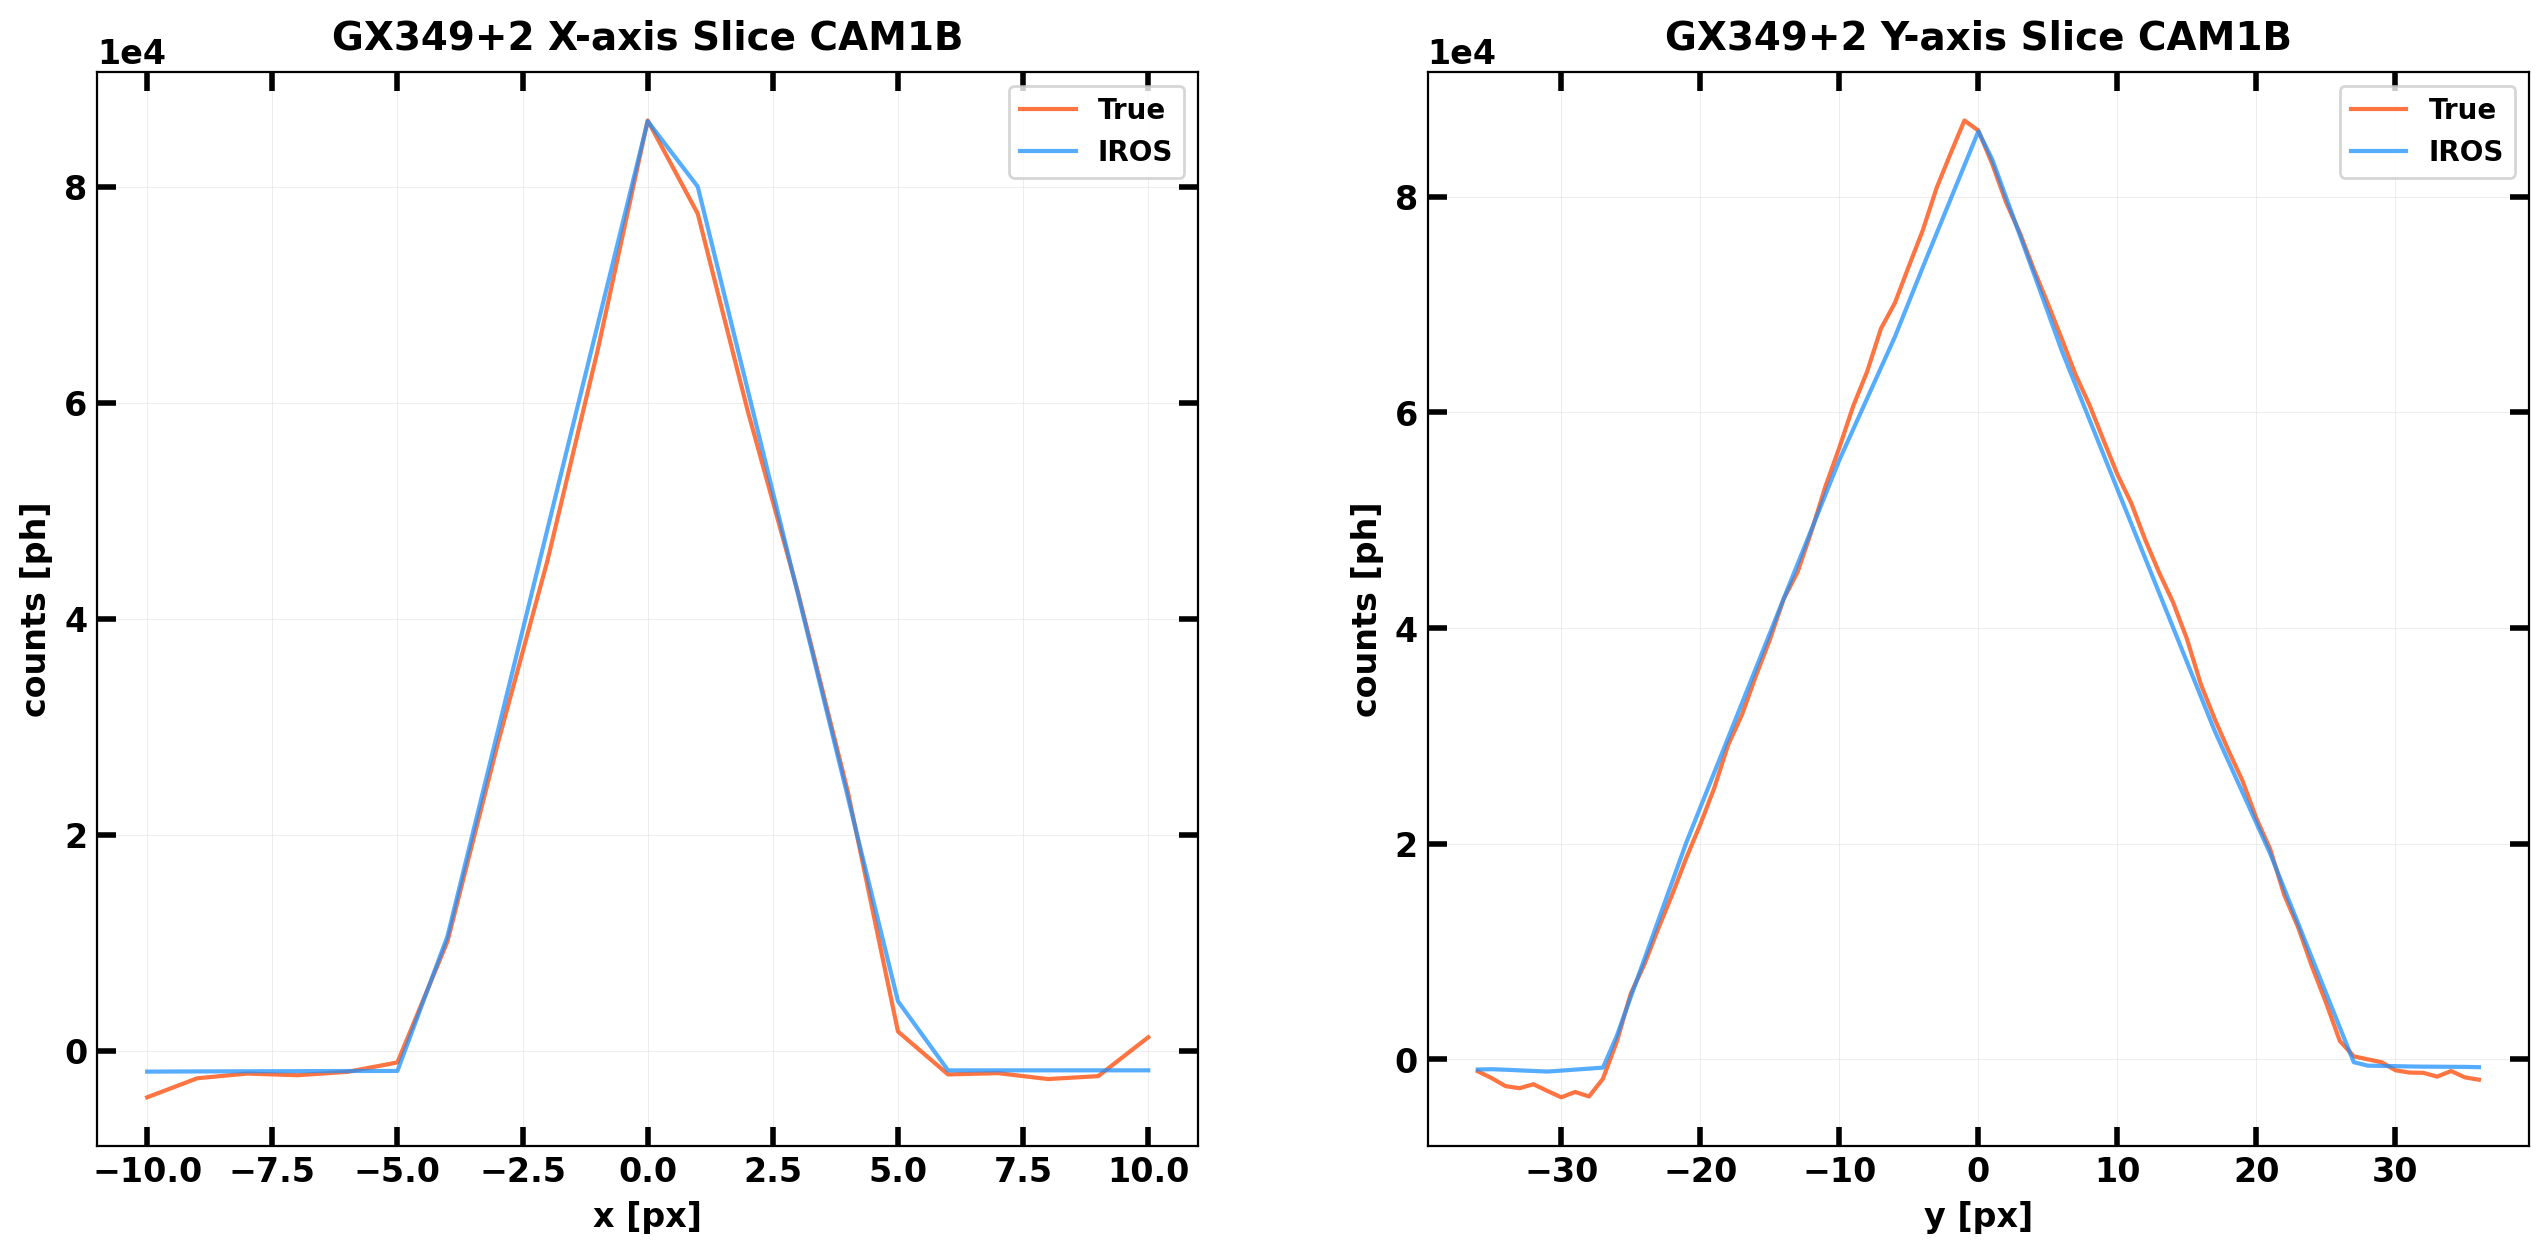

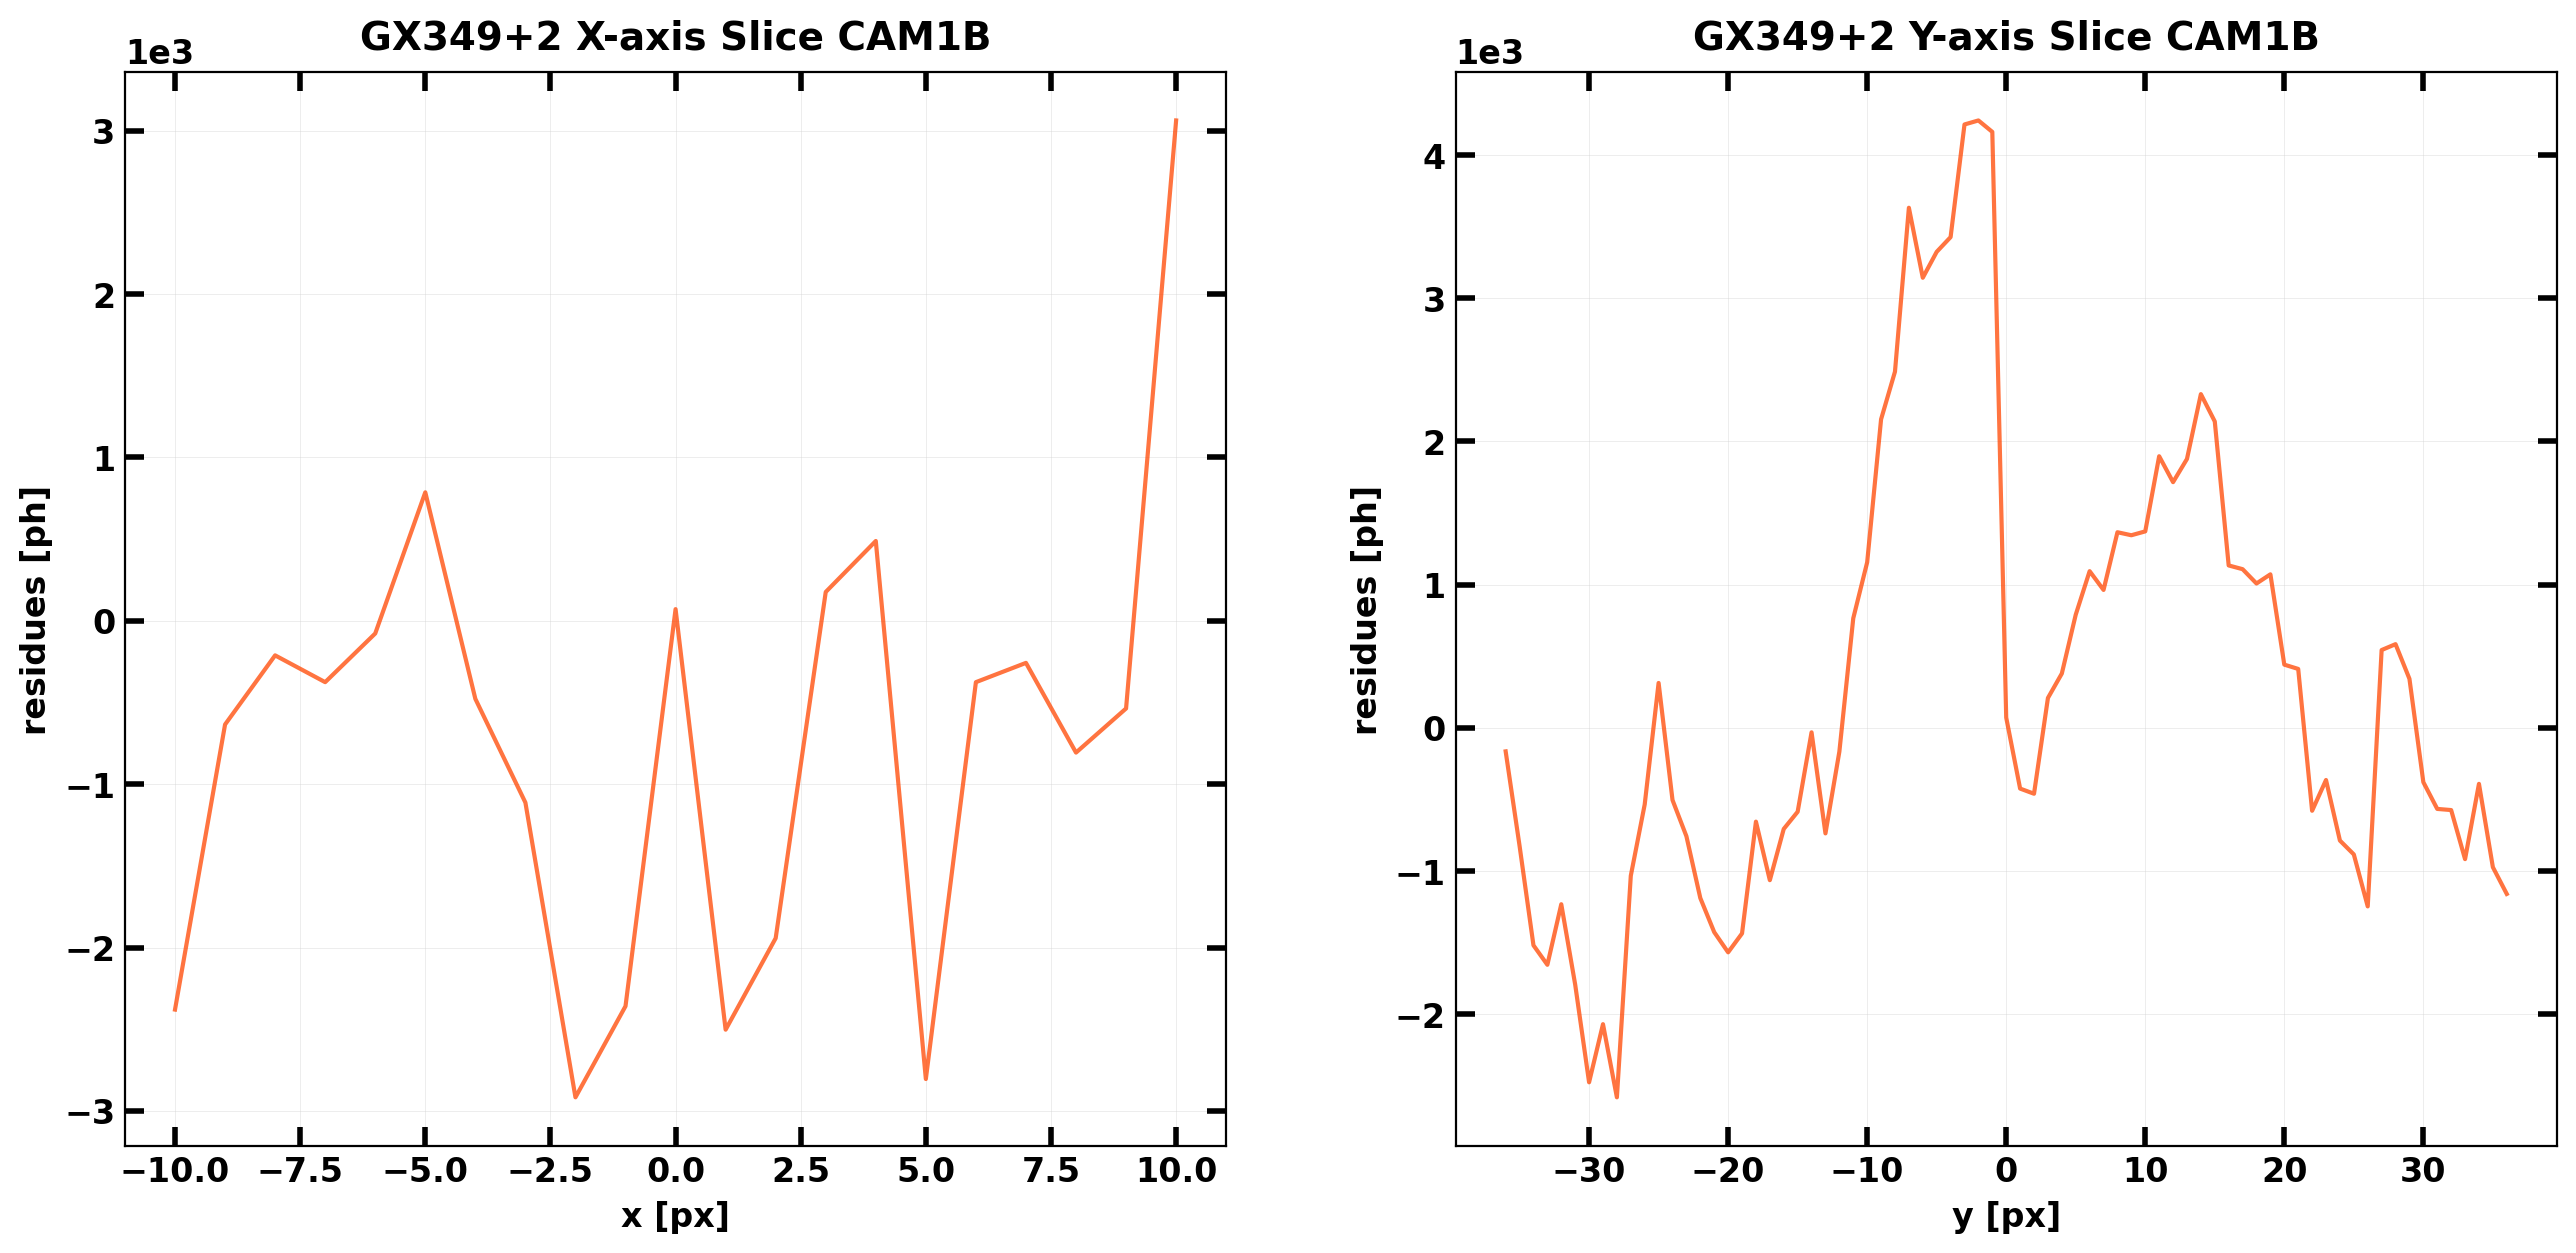

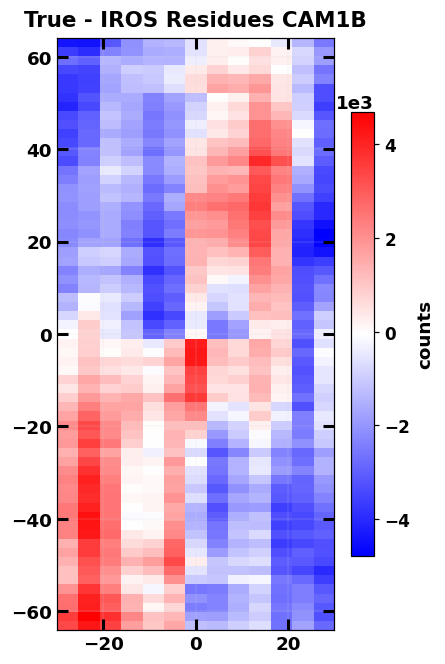

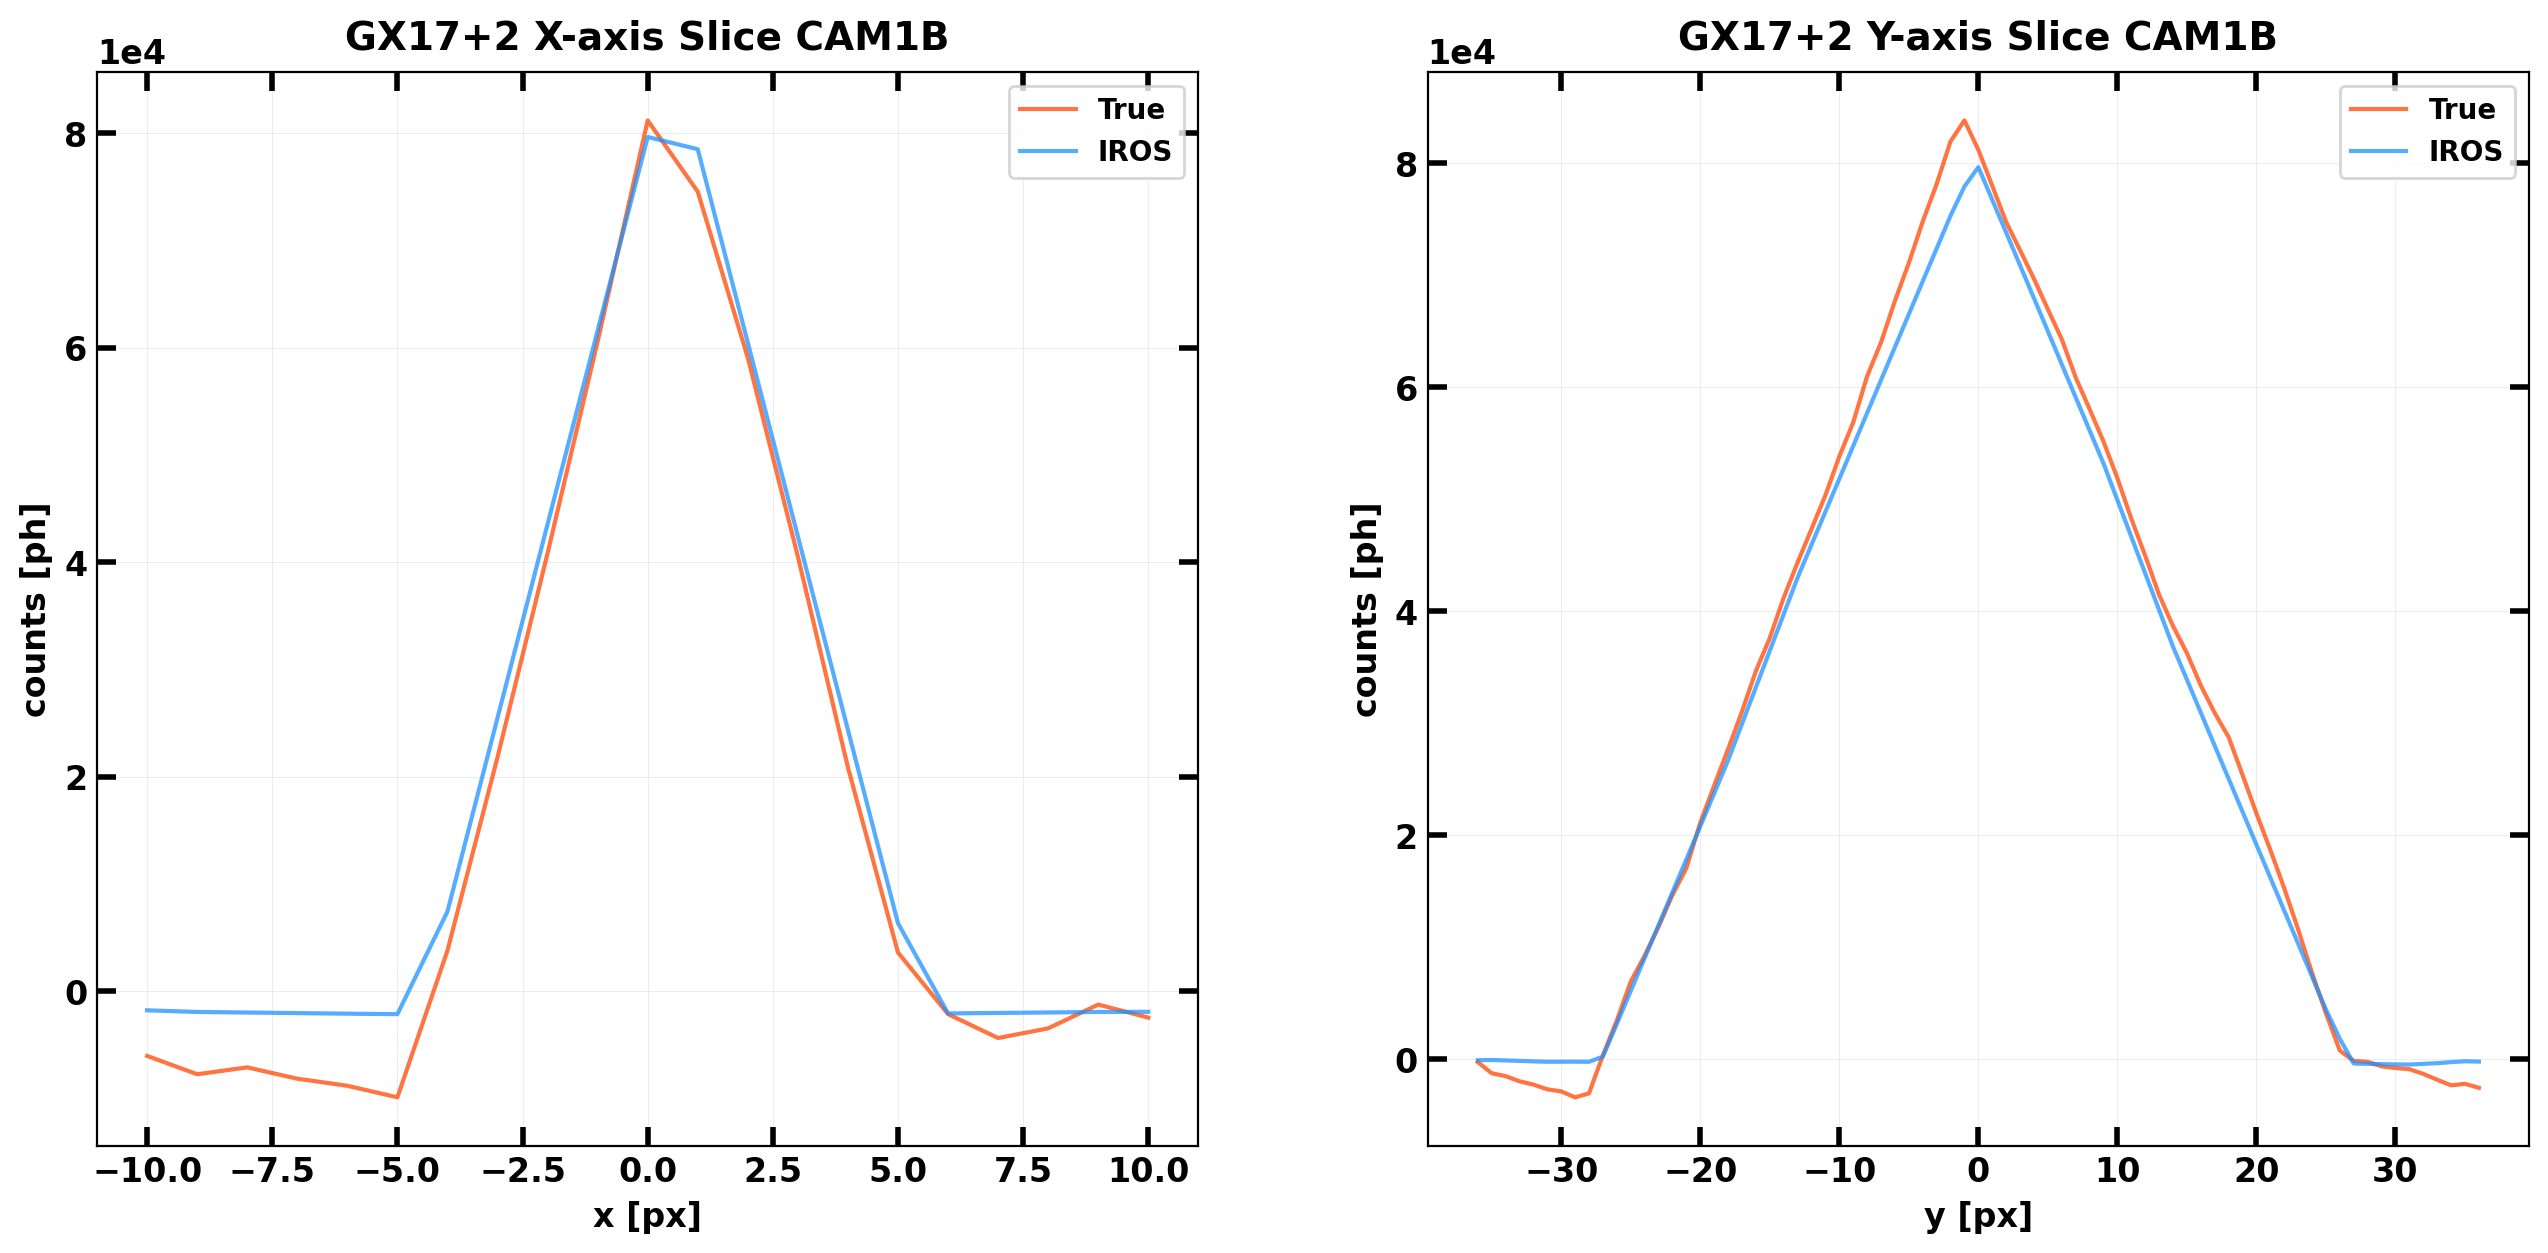

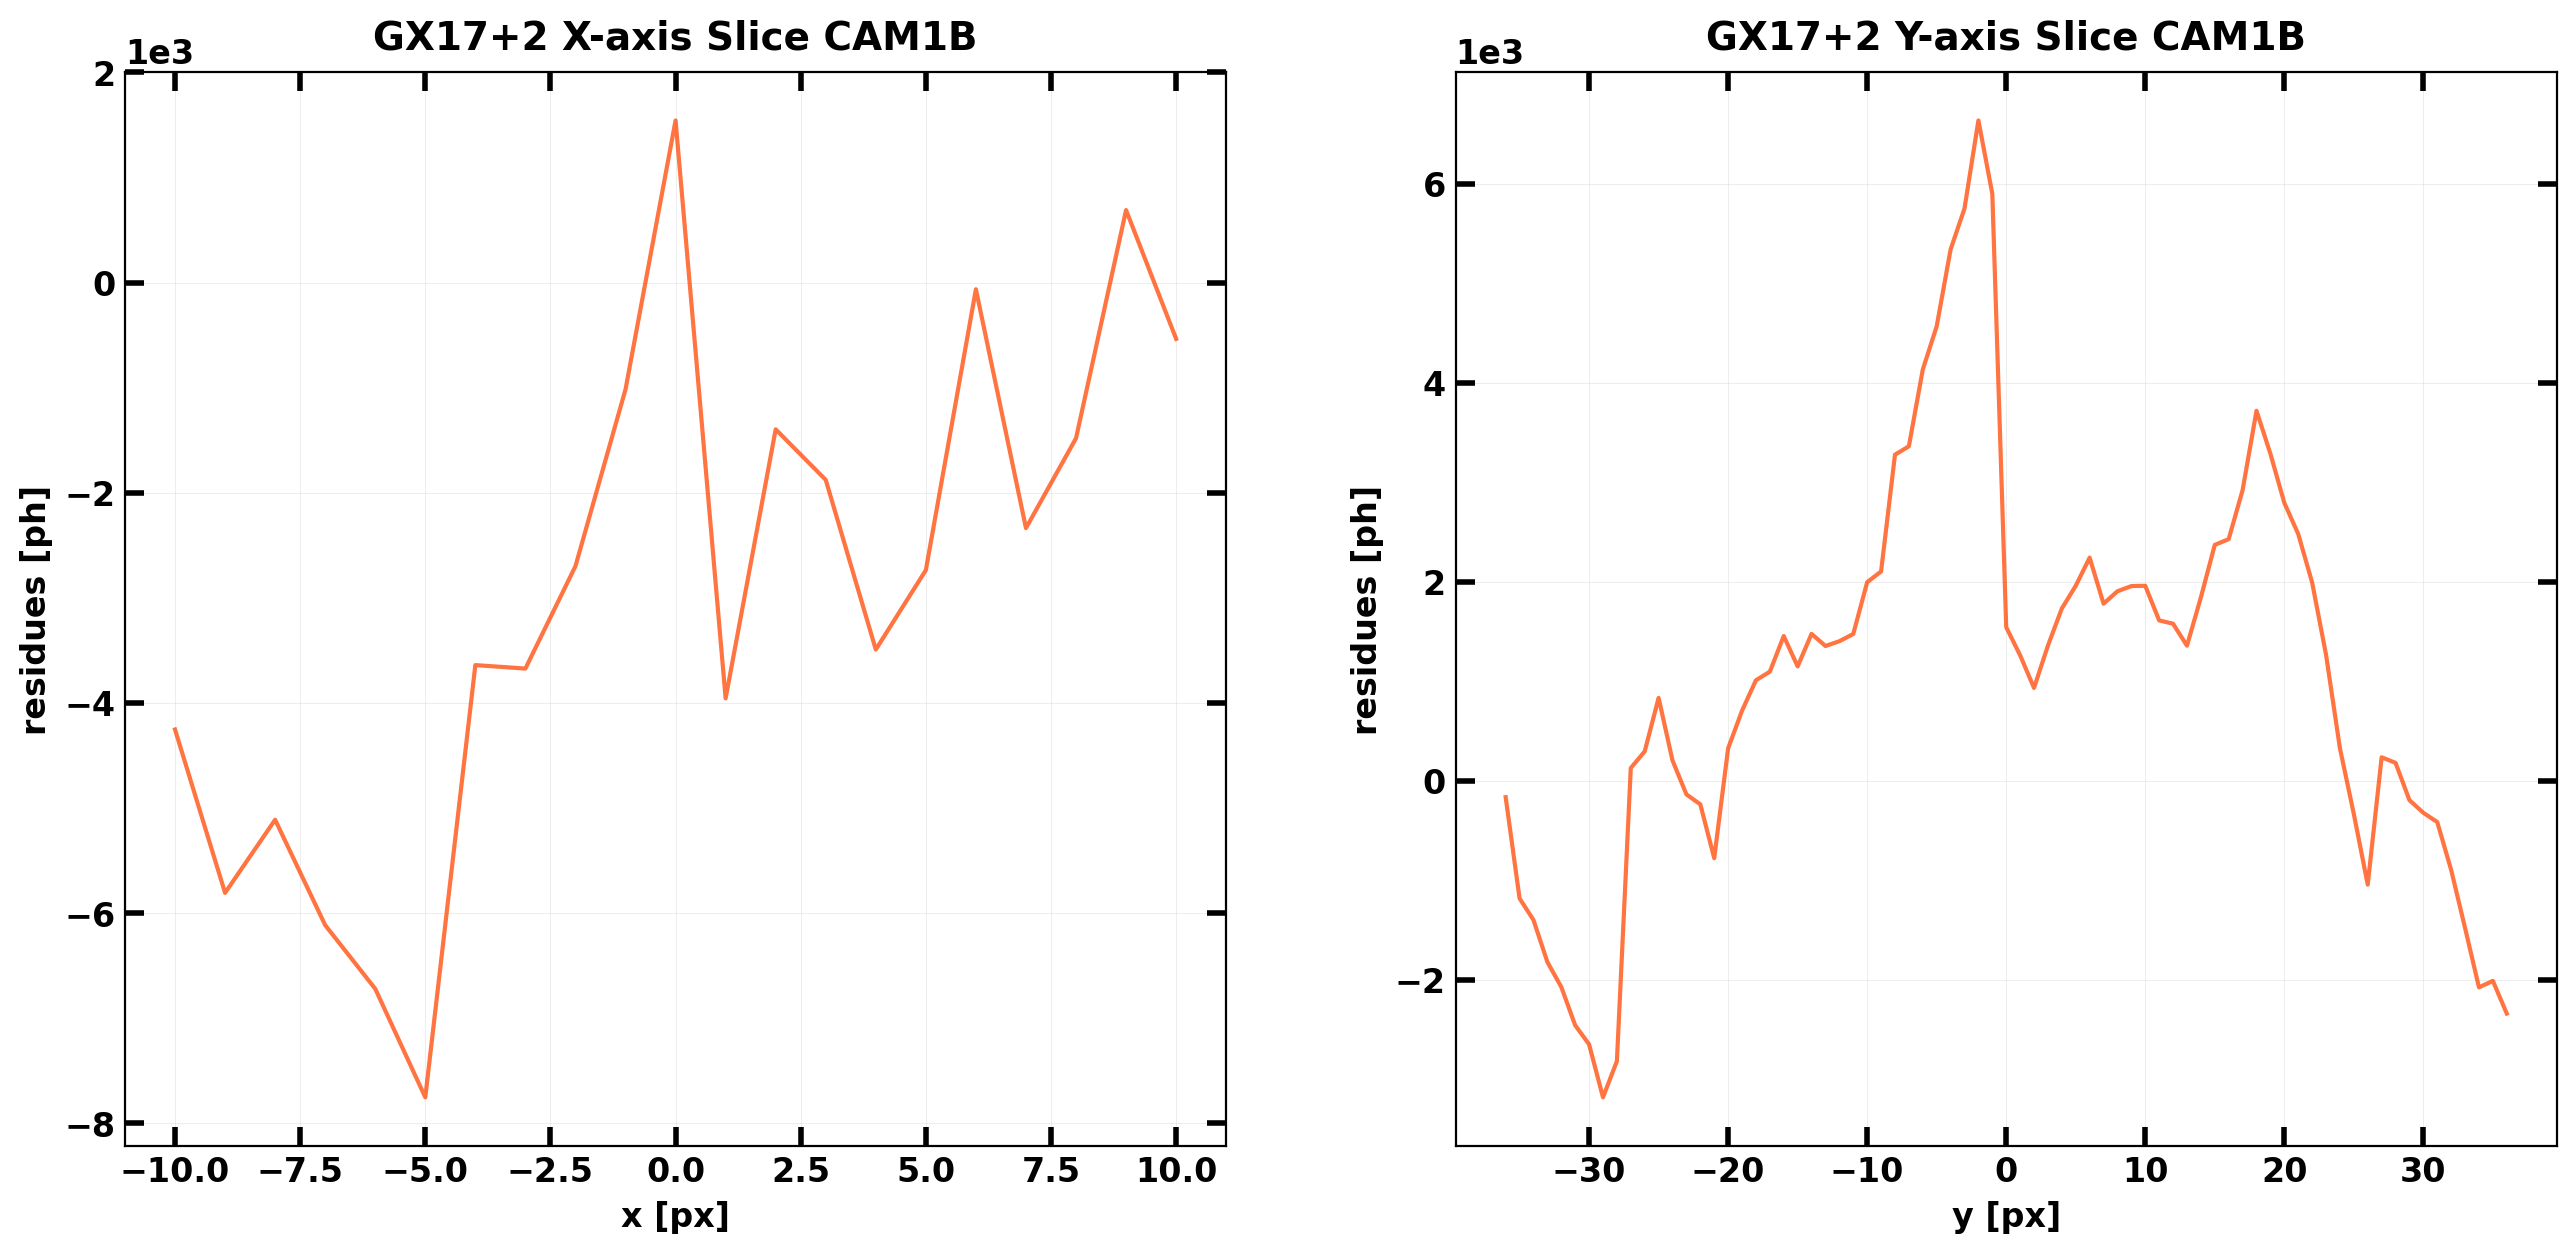

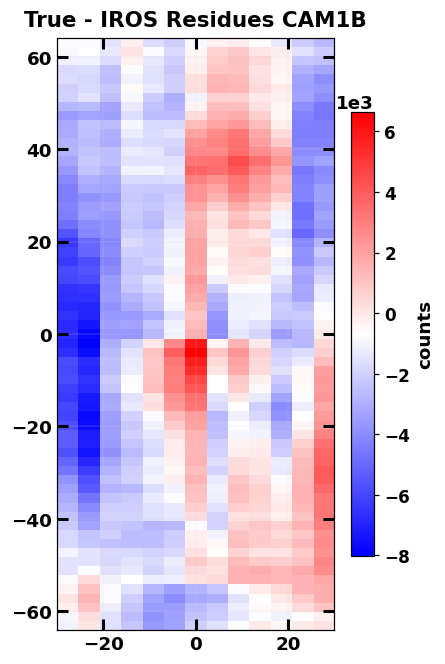

In [ ]:
#assert False

#### test SCOX-1 PSF with:
#       - real mask
#       - ideal detector
#       - vignetting OFF

crp = (
    int(wfm.specs["slit_deltay"] * UPY / wfm.specs["mask_deltay"] + 5),
    int(wfm.specs["slit_deltax"] * UPX / wfm.specs["mask_deltax"] + 5),
)
ds.reconstruction_plot(
    true_sky=simul_sky_camA,
    log=log_camA,
    crp=crp,
    camera=wfm,
    vignetting=False,
    psfy=False,
    #savepath=is_img,
)
ds.reconstruction_plot(
    true_sky=simul_sky_camB,
    log=log_camB,
    crp=crp,
    camera=wfm,
    vignetting=False,
    psfy=False,
    #savepath=is_img,
)

In [3]:
assert False

#### test source profiles wrt fluence and vignetting effect

from numpy.typing import NDArray

from bloodmoon.coords import angle2shift, shift2pos
from bloodmoon.mask import CodedMaskCamera
from bloodmoon.optim import model_sky


def sources_profiles(
    shift_x: float,
    shift_y: float,
    fluence: float | tuple[float, ...],
    camera: CodedMaskCamera,
    vignetting: bool,
    psfy: bool,
) -> tuple[NDArray]:
    """
    Computes sources models for input fluences.
    """
    skies = []

    for f in fluence:
        sky = model_sky(
            camera, shift_x, shift_y, f, vignetting, psfy,
        )
        skies.append(sky)
    
    return tuple(skies)

VIGNETTING = True
PSFY = False

angle_x, angle_y = 0.0, 0.0
shift_x, shift_y = map(
    lambda x: angle2shift(wfm, x),
    (angle_x, angle_y),
)
fluences = (
    1e3, 4e3, 7e3, 1e4
)
skies = sources_profiles(shift_x, shift_y, fluences, wfm, VIGNETTING, PSFY)
skies_ideal = sources_profiles(shift_x, shift_y, fluences, wfm, False, False)

crp = (
    int(wfm.specs['slit_deltay'] * wfm.upscale_f.y / wfm.specs['mask_deltay'] + 5),
    int(wfm.specs['slit_deltax'] * wfm.upscale_f.x / wfm.specs['mask_deltax'] + 5),
)
pos = shift2pos(wfm, shift_x, shift_y)
ds.slices_plot(
    sky=skies,
    pos=pos,
    crp=crp,
    source=f'({angle_x}, {angle_y}) deg',
    labels=tuple(
        f'f = {int(f)}' for f in fluences
    ),
    #save_to='/mnt/d/PhD_AASS/Coding/Images_fits/profiles_vignetting.png',
)
ds.slices_plot(
    sky=skies_ideal,
    pos=pos,
    crp=crp,
    source=f'IDEAL ({angle_x}, {angle_y}) deg',
    labels=tuple(
        f'f = {int(f)}' for f in fluences
    ),
    #save_to='/mnt/d/PhD_AASS/Coding/Images_fits/profiles_ideal.png',
)
ds.slices_plot(
    sky=tuple(
        s_ideal - s for s_ideal, s in zip(skies_ideal, skies)
    ),
    pos=pos,
    crp=crp,
    source=f'Ideal - Real Residues',
    labels=tuple(
        f'f = {int(f)}' for f in fluences
    ),
    #save_to='/mnt/d/PhD_AASS/Coding/Images_fits/profiles_residues.png',
)

AssertionError: 